# Комплексный Исследовательский Проект: Анализ Коллекции MoMA

**Цель:** Провести всесторонний анализ коллекции Музея современного искусства (MoMA), ответив на 4 базовых вопроса и реализовав 10 продвинутых исследовательских концепций с использованием статистики, машинного обучения, NLP и компьютерного зрения.

---

## 1. Настройка Окружения, Загрузка и Очистка Данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re

# Продвинутые библиотеки
from lifelines import CoxPHFitter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import nltk
import networkx as nx

# Загрузка стоп-слов для NLP
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
from nltk.corpus import stopwords

# --- Загрузка данных ---
try:
    # Предполагается, что файлы находятся в текущей директории
    df_artworks = pd.read_csv('Artworks.csv', low_memory=False)
    df_artists = pd.read_csv('Artists.csv', low_memory=False)
    df_data_dict = pd.read_csv('MoMA_data_dictionary.csv', low_memory=False)
    
    # Загрузка MoMA_OnView из Excel
    df_onview = pd.read_excel('MoMA_OnView.xlsx', sheet_name='Artworks')
    df_onview.columns = df_onview.columns.astype(str).str.strip()  # на всякий случай
    print(df_onview.columns.tolist())

    print("Данные успешно загружены.")
except FileNotFoundError as e:
    print(f"ОШИБКА: Убедитесь, что файлы датасетов находятся в этой же директории. Не найден файл: {e.filename}")
    df_artworks = pd.DataFrame()
    df_artists = pd.DataFrame()
    df_onview = pd.DataFrame()
    df_data_dict = pd.DataFrame()

df_artworks['ConstituentID'] = pd.to_numeric(df_artworks['ConstituentID'], errors='coerce').astype('Int64')
df_artists['ConstituentID']  = pd.to_numeric(df_artists['ConstituentID'],  errors='coerce').astype('Int64')

# df_artworks = df_artworks.dropna(subset=['ConstituentID'])
# df_artists  = df_artists.dropna(subset=['ConstituentID'])
for d in [df_artworks, df_artists, df_onview, df_data_dict]:
    if not d.empty:
        d.columns = d.columns.astype(str).str.strip()
# теперь merge
df = df_artworks.merge(
    df_artists[['ConstituentID', 'Gender', 'Nationality', 'DisplayName']],
    on='ConstituentID',
    how='left',
    suffixes=('_work', '_artist')
)
# --- Предварительная очистка и объединение ---
if not df_artworks.empty and not df_artists.empty:
    # Объединение данных о работах и художниках
    df = df_artworks.merge(df_artists[['ConstituentID', 'Gender', 'Nationality', 'DisplayName']], 
                           on='ConstituentID', 
                           how='left', 
                           suffixes=('_work', '_artist'))
    
    # Преобразование дат
    onview_ids = set(pd.to_numeric(df_onview['ObjectID'], errors='coerce').dropna().astype(int).unique())
    df['DateAcquired'] = pd.to_datetime(df['DateAcquired'], errors='coerce')
    df['Date_Created'] = pd.to_numeric(df['Date'], errors='coerce')
    
    # Добавление флага OnView из отдельного датасета
    if not df_onview.empty:
        onview_ids = set(df_onview['ObjectID'].unique())
        df['Is_OnView'] = df['ObjectID'].apply(lambda x: 1 if x in onview_ids else 0)
    else:
        # Если MoMA_OnView.xlsx не загружен, используем столбец OnView из artworks
        df['Is_OnView'] = df['OnView'].apply(lambda x: 1 if x == 'Y' else 0)
        
    print("Данные объединены и очищены.")
    print(f"Общее количество работ для анализа: {len(df)}")

['ObjectID', 'Title', 'ConstituentID', 'Date', 'Medium', 'Dimensions', 'Classification', 'Department', 'DateAcquired', 'URL', 'ImageURL', 'OnView']
Данные успешно загружены.
Данные объединены и очищены.
Общее количество работ для анализа: 157630


In [2]:
print("Artists columns:", df_artists.columns.tolist())

Artists columns: ['ConstituentID', 'DisplayName', 'ArtistBio', 'Nationality', 'Gender', 'BeginDate', 'EndDate', 'Wiki QID', 'ULAN']


In [9]:
df.columns.tolist()

['Title',
 'Artist',
 'ConstituentID',
 'ArtistBio',
 'Nationality_work',
 'BeginDate',
 'EndDate',
 'Gender_work',
 'Date',
 'Medium',
 'Dimensions',
 'CreditLine',
 'AccessionNumber',
 'Classification',
 'Department',
 'DateAcquired',
 'Cataloged',
 'ObjectID',
 'URL',
 'ImageURL',
 'OnView',
 'Circumference (cm)',
 'Depth (cm)',
 'Diameter (cm)',
 'Height (cm)',
 'Length (cm)',
 'Weight (kg)',
 'Width (cm)',
 'Seat Height (cm)',
 'Duration (sec.)',
 'Gender_artist',
 'Nationality_artist',
 'DisplayName',
 'Date_Created',
 'Is_OnView']

## 1.1. Словарь Данных (MoMA_data_dictionary)

In [3]:
if not df_data_dict.empty:
    print("Словарь данных MoMA:")
    # Вывод словаря данных для удобства
    display(df_data_dict)
else:
    print("Словарь данных не загружен.")

Словарь данных MoMA:


,Table,Field,Description
0,Artworks,Title,The name or title of the artwork.
1,Artworks,Artist,The name of the artist(s) who created the artw...
2,Artworks,ConstituentID,Unique identifier(s) for the artist(s) related...
3,Artworks,ArtistBio,A short biography or background information ab...
4,Artworks,Nationality,The country or region of origin of the artist.
5,Artworks,BeginDate,The year the artist was born.
6,Artworks,EndDate,The year the artist passed away.
7,Artworks,Gender,The gender of the artist.
8,Artworks,Date,The date or year the artwork was created.
9,Artworks,Medium,"The material(s) used to create the artwork, su..."


---

## 2. Базовый Описательный Анализ (4 Вопроса Пользователя)


--- Q1: Современность произведений искусства ---


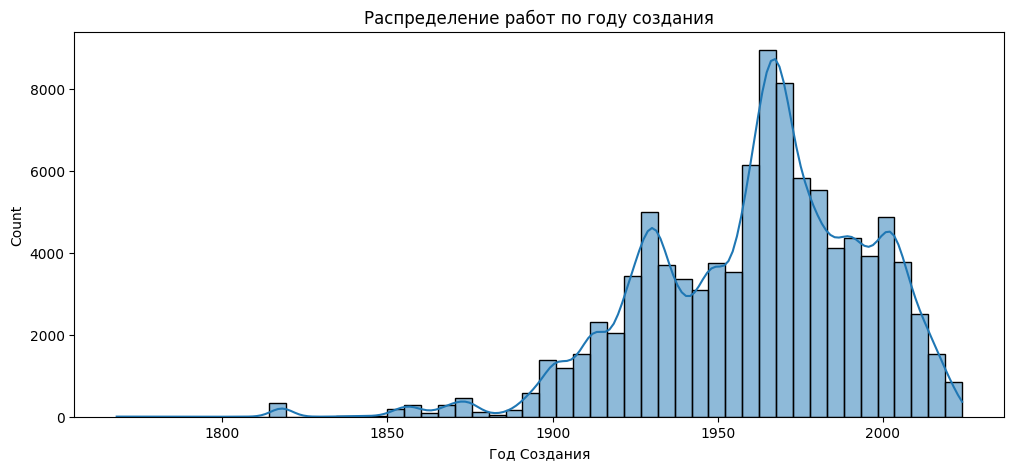

Медианный год создания: 1966

--- Q2: Топ-10 наиболее представленных художников ---


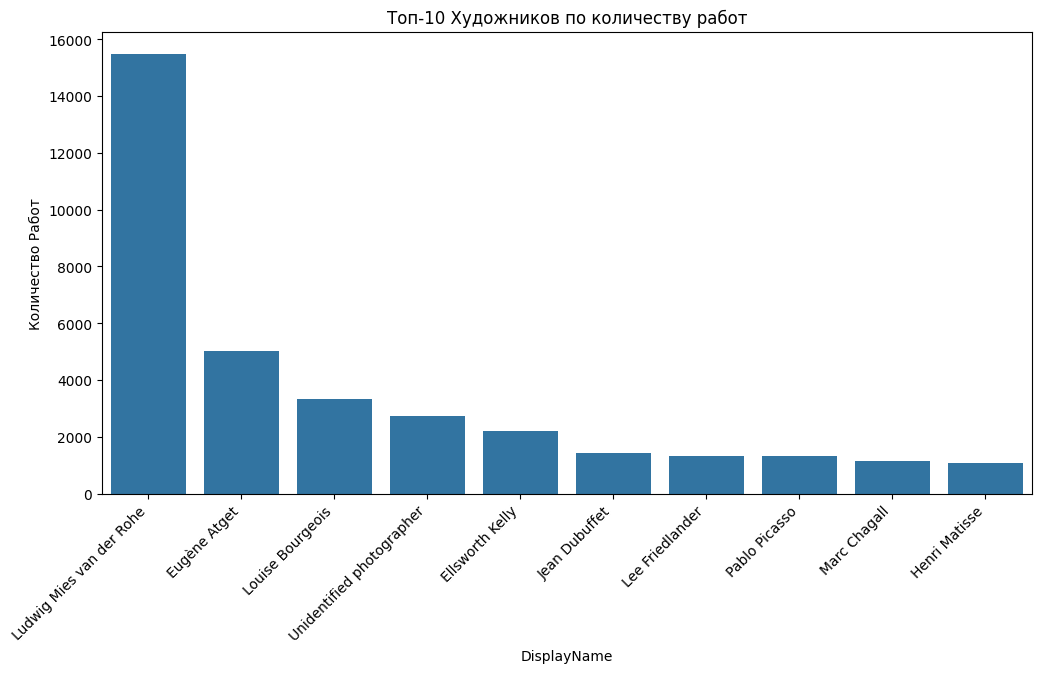


--- Q3: Тенденции в датах приобретения ---


C:\Users\Shaim\AppData\Local\Temp\ipykernel_31108\257711610.py:25: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  acq_counts = df_acq.resample('Y').size()


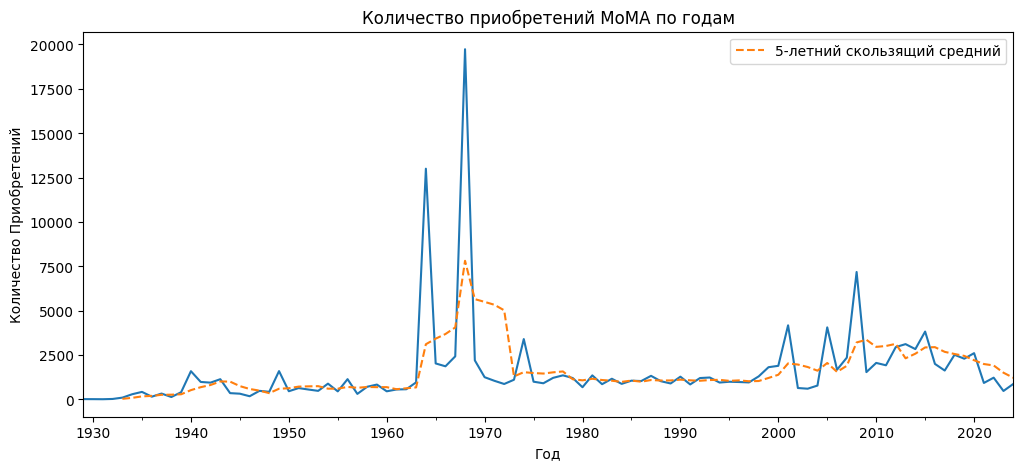


--- Q4: Распространенность видов искусства (Classification) ---


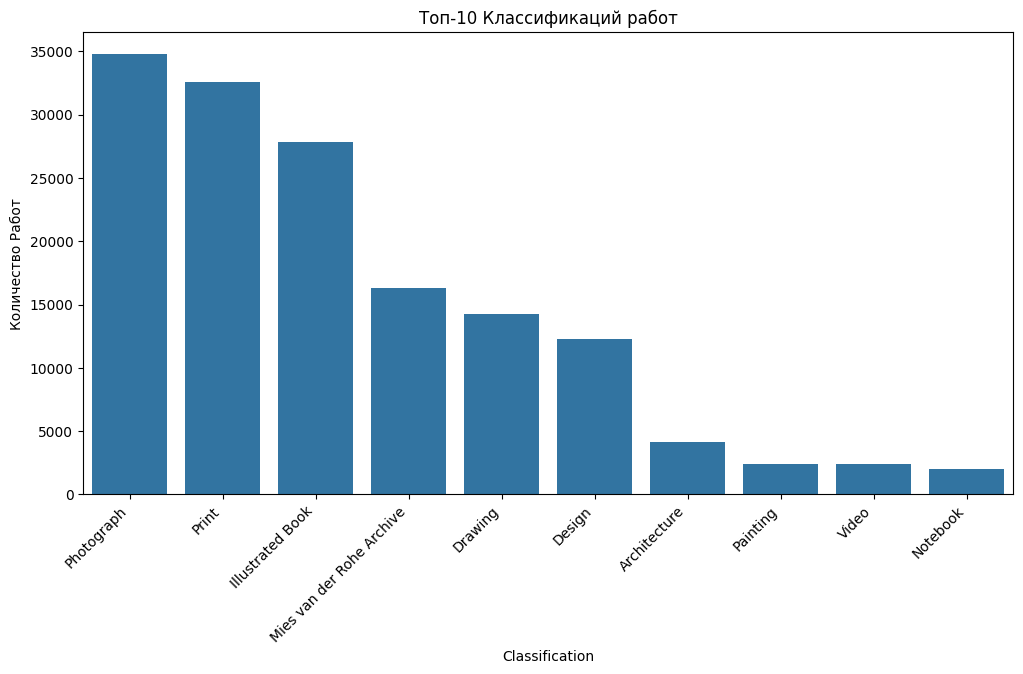

In [4]:
if not df.empty:
    # --- Q1: Насколько современны произведения искусства? ---
    print("\n--- Q1: Современность произведений искусства ---")
    df_dates = df.dropna(subset=['Date_Created'])
    plt.figure(figsize=(12, 5))
    sns.histplot(df_dates['Date_Created'], bins=50, kde=True)
    plt.title('Распределение работ по году создания')
    plt.xlabel('Год Создания')
    plt.show()
    print(f"Медианный год создания: {df_dates['Date_Created'].median():.0f}")
    
    # --- Q2: Какие артисты представлены чаще всего? ---
    print("\n--- Q2: Топ-10 наиболее представленных художников ---")
    top_artists = df['DisplayName'].value_counts().nlargest(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_artists.index, y=top_artists.values)
    plt.xticks(rotation=45, ha='right')
    plt.title('Топ-10 Художников по количеству работ')
    plt.ylabel('Количество Работ')
    plt.show()
    
    # --- Q3: Наблюдаются ли какие-либо тенденции в датах приобретения? ---
    print("\n--- Q3: Тенденции в датах приобретения ---")
    df_acq = df.dropna(subset=['DateAcquired']).set_index('DateAcquired')
    acq_counts = df_acq.resample('Y').size()
    plt.figure(figsize=(12, 5))
    acq_counts.plot()
    acq_counts.rolling(window=5).mean().plot(label='5-летний скользящий средний', linestyle='--')
    plt.title('Количество приобретений MoMA по годам')
    plt.xlabel('Год')
    plt.ylabel('Количество Приобретений')
    plt.legend()
    plt.show()
    
    # --- Q4: Какие виды произведений искусства наиболее распространены? ---
    print("\n--- Q4: Распространенность видов искусства (Classification) ---")
    top_classifications = df['Classification'].value_counts().nlargest(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_classifications.index, y=top_classifications.values)
    plt.xticks(rotation=45, ha='right')
    plt.title('Топ-10 Классификаций работ')
    plt.ylabel('Количество Работ')
    plt.show()

---

## 3. Продвинутый Анализ (10 Концепций)

### 3.1. Прогнозирование «Живучести» Искусства (Survival Analysis)

In [12]:
import numpy as np
import pandas as pd
from datetime import datetime
from lifelines import CoxPHFitter

def normalize_gender(x):
    if pd.isna(x): 
        return np.nan
    s = str(x).strip().lower()
    if s in {"male", "m"}:
        return "Male"
    if s in {"female", "f"}:
        return "Female"
    # всё остальное (non-binary, transgender..., gender non-conforming, etc.)
    return "Other/Unknown"

df_survival = df.dropna(subset=['DateAcquired', 'Is_OnView']).copy()

# гендер/национальность художника (берём *_artist)
df_survival['Gender'] = df_survival['Gender_artist'].apply(normalize_gender)
df_survival['Nationality'] = df_survival['Nationality_artist'].astype(str).str.strip()

# T и E
today = datetime.now()
df_survival['T'] = (today - df_survival['DateAcquired']).dt.days / 365.25
df_survival = df_survival[(df_survival['T'] > 0) & np.isfinite(df_survival['T'])]

df_survival['E'] = 1 - df_survival['Is_OnView'].astype(int)

# выбросим пустые gender/nationality
df_survival = df_survival.dropna(subset=['Gender', 'Nationality'])
top_nationalities = df_survival['Nationality'].value_counts().nlargest(8).index
df_survival['Nationality_Grouped'] = df_survival['Nationality'].where(
    df_survival['Nationality'].isin(top_nationalities),
    'Other'
)

X = pd.get_dummies(df_survival[['Gender', 'Nationality_Grouped']], drop_first=True)

# убираем дамми, где слишком мало единиц (редкие категории)
min_ones = 50  # можно 20/100 в зависимости от размера данных
keep = (X.sum(axis=0) >= min_ones) & ((len(X) - X.sum(axis=0)) >= min_ones)
X = X.loc[:, keep]

df_survival_final = pd.concat([df_survival[['T', 'E']], X], axis=1)

print("rows:", len(df_survival_final), "features:", df_survival_final.shape[1]-2)
print("dropped rare columns:", (keep == False).sum())


rows: 134984 features: 10
dropped rare columns: 0


In [13]:
cph = CoxPHFitter(penalizer=0.1)  # попробуй 0.01 / 0.1 / 1.0
cph.fit(df_survival_final, duration_col='T', event_col='E')
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 134984 total observations, 1012 right-censored observations>
             duration col = 'T'
                event col = 'E'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 134984
number of events observed = 133972
   partial log-likelihood = -1442661.32
         time fit was run = 2025-12-24 20:37:42 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
Gender_Male                  -0.59      0.55      0.01           -0.61           -0.58                0.55                0.56
Gender_Other/Unknown          2.08      7.99      0.12            1.84            2.32                6.30               10.15
Nationality_Grouped_British  -0.07      0.94      0.01           -0.09           -0.04                0.91                0.96
Nationality_Grouped_French   -0.43      0.65      0.01           -0.45           -0.42                0.64                0.66
Nationality_Grouped_German   -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
Nationality_Grouped_Italian   0.05      1.06      0.02            0.02            0.09                1.02                1.10
Nationality_Grouped_Japanese  0.24      1.27      0.02            0.20            0.28                1.22                1.32
Nationality_Grouped_Other     0.22      1.24      0.01            0.20            0.23                1.22                1.26
Nationality_Grouped_Russian   0.14      1.15      0.02            0.10            0.19                1.11                1.20
Nationality_Grouped_Spanish  -0.41      0.67      0.02           -0.44           -0.37                0.64                0.69

                              cmp to      z      p  -log2(p)
covariate                                                   
Gender_Male                     0.00 -74.45 <0.005       inf
Gender_Other/Unknown            0.00  17.07 <0.005    214.64
Nationality_Grouped_British     0.00  -4.91 <0.005     20.07
Nationality_Grouped_French      0.00 -58.56 <0.005       inf
Nationality_Grouped_German      0.00  -4.66 <0.005     18.25
Nationality_Grouped_Italian     0.00   2.91 <0.005      8.12
Nationality_Grouped_Japanese    0.00  11.66 <0.005    101.94
Nationality_Grouped_Other       0.00  28.07 <0.005    573.69
Nationality_Grouped_Russian     0.00   6.77 <0.005     36.19
Nationality_Grouped_Spanish     0.00 -22.86 <0.005    381.74
---
Concordance = 0.63
Partial AIC = 2885342.63
log-likelihood ratio test = 12603.01 on 10 df
-log2(p) of ll-ratio test = inf

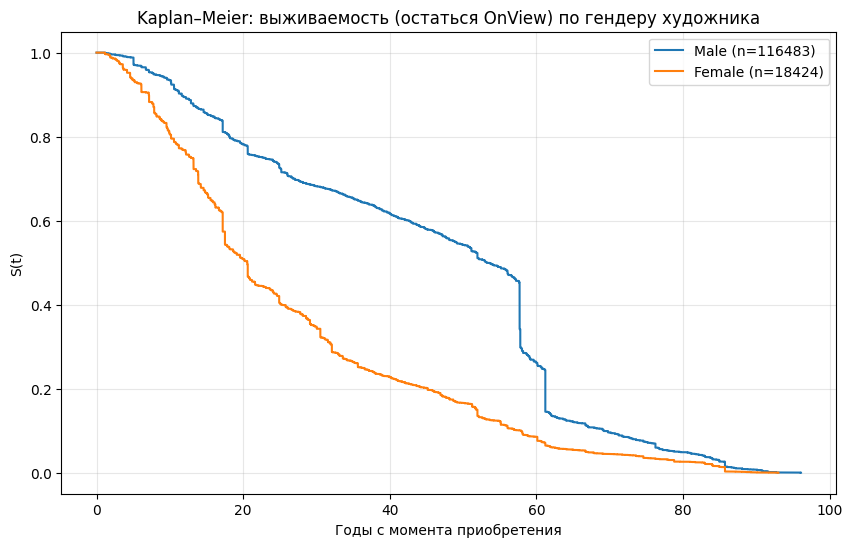

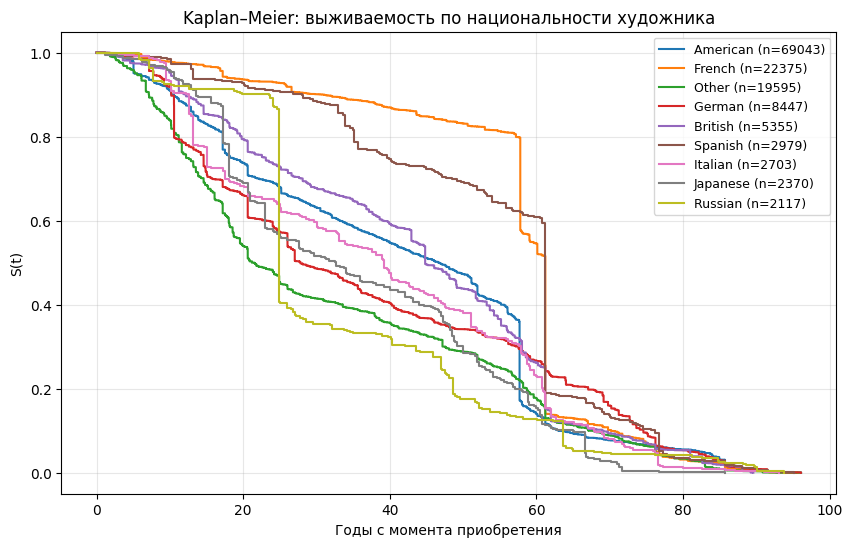

In [22]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# 1) KM по гендеру
kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))
for g in ["Male", "Female", "Other/Unknown"]:
    sub = df_survival[df_survival["Gender"] == g]
    if len(sub) < 200:  # фильтр на слишком маленькие группы (можешь убрать)
        continue
    kmf.fit(durations=sub["T"], event_observed=sub["E"], label=f"{g} (n={len(sub)})")
    kmf.plot_survival_function(ci_show=False)
plt.title("Kaplan–Meier: выживаемость (остаться OnView) по гендеру художника")
plt.xlabel("Годы с момента приобретения")
plt.ylabel("S(t)")
plt.grid(True, alpha=0.3)
plt.show()

# 2) KM по национальности (топ-8 + Other)
top_groups = df_survival["Nationality_Grouped"].value_counts().head(9).index  # чтобы не было слишком много линий

plt.figure(figsize=(10, 6))
for nat in top_groups:
    sub = df_survival[df_survival["Nationality_Grouped"] == nat]
    if len(sub) < 300:
        continue
    kmf.fit(durations=sub["T"], event_observed=sub["E"], label=f"{nat} (n={len(sub)})")
    kmf.plot_survival_function(ci_show=False)
plt.title("Kaplan–Meier: выживаемость по национальности художника")
plt.xlabel("Годы с момента приобретения")
plt.ylabel("S(t)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.show()


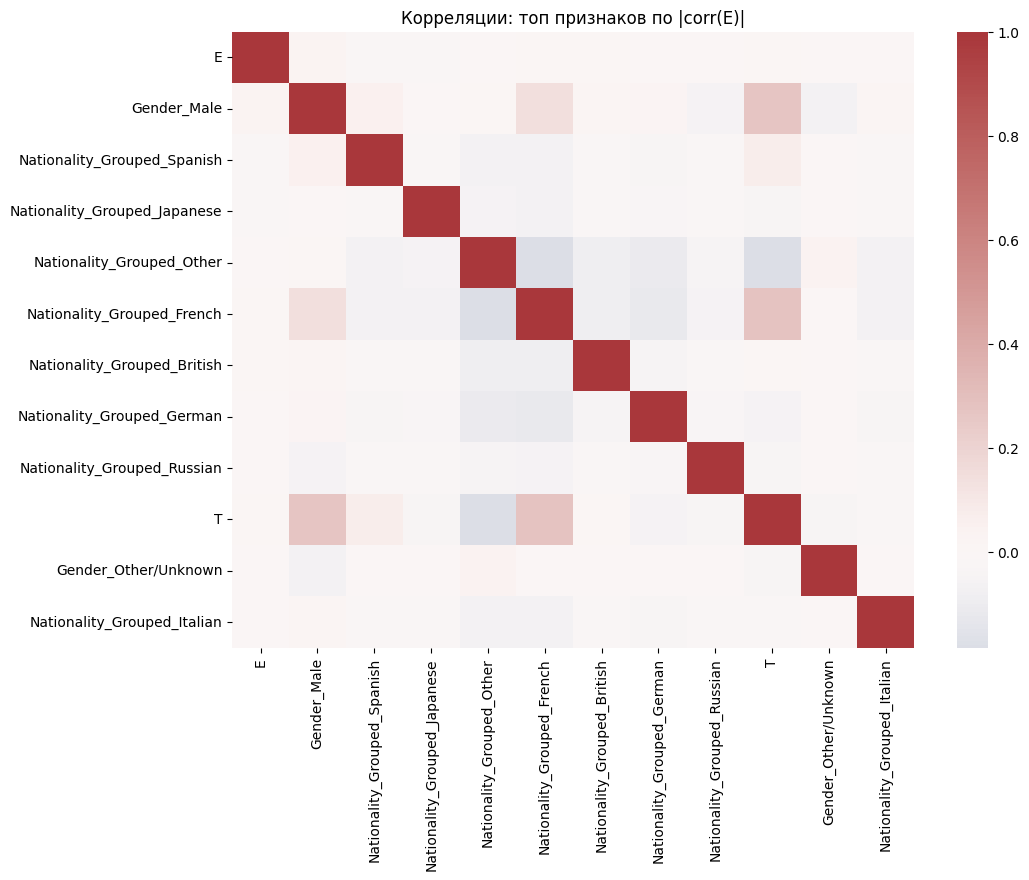

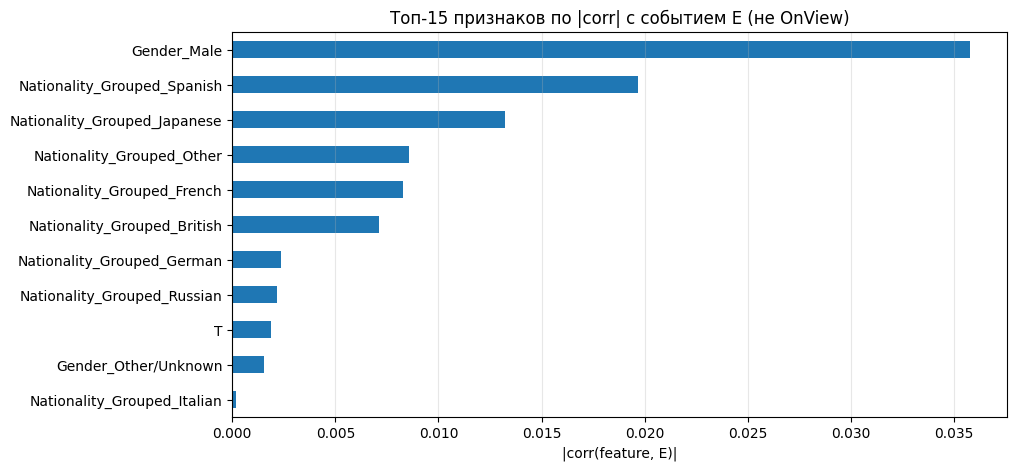

In [23]:
import seaborn as sns

# Соберём матрицу для корреляций: дамми + T + E
corr_df = pd.concat([df_survival[["T", "E"]].reset_index(drop=True), X.reset_index(drop=True)], axis=1)

# 1) heatmap корреляций (если признаков много — берём топ-25 по связи с E)
corr_with_E = corr_df.corr(numeric_only=True)["E"].abs().sort_values(ascending=False)
top_feats = corr_with_E.head(25).index  # E тоже попадёт — это ок
corr_top = corr_df[top_feats].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr_top, annot=False, cmap="vlag", center=0)
plt.title("Корреляции: топ признаков по |corr(E)|")
plt.show()

# 2) barplot: топ признаков по корреляции с событием E
top_E = corr_with_E.drop("E").head(15)

plt.figure(figsize=(10, 5))
top_E.sort_values().plot(kind="barh")
plt.title("Топ-15 признаков по |corr| с событием E (не OnView)")
plt.xlabel("|corr(feature, E)|")
plt.grid(True, axis="x", alpha=0.3)
plt.show()


### 3.2. Семантическая Кластеризация Названий (NLP/LDA)

In [14]:
if not df.empty:
    print("\n--- 3.2. Семантическая Кластеризация Названий (LDA) ---")
    
    # Очистка текста
    def clean_text(text):
        if pd.isna(text): return ''
        text = str(text).lower()
        text = re.sub(r'[^a-z\s]', '', text) 
        return text
    
    df_nlp = df.dropna(subset=['Title']).copy()
    df_nlp['Clean_Title'] = df_nlp['Title'].apply(clean_text)
    
    stop_words = set(stopwords.words('english'))
    
    # Векторизация с TF-IDF
    tfidf_vectorizer = TfidfVectorizer(
        max_df=0.95, 
        min_df=5, 
        stop_words=stop_words
    )
    
    try:
        tfidf = tfidf_vectorizer.fit_transform(df_nlp['Clean_Title'])
        
        # Тематическое моделирование с LDA
        NUM_TOPICS = 8 
        lda = LatentDirichletAllocation(
            n_components=NUM_TOPICS, 
            random_state=42
        )
        lda.fit(tfidf)
        
        # Функция для вывода топ-слов
        def display_topics(model, feature_names, no_top_words):
            for topic_idx, topic in enumerate(model.components_):
                print(f"Тема {topic_idx + 1}: {' '.join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]])}")
        
        print("\nРезультаты LDA (Топ-8 тем по названиям работ):")
        display_topics(lda, tfidf_vectorizer.get_feature_names_out(), 10)
        
    except ValueError as e:
        print(f"Ошибка при векторизации/LDA: {e}. Проверьте наличие достаточного количества данных.")


--- 3.2. Семантическая Кластеризация Названий (LDA) ---
Ошибка при векторизации/LDA: The 'stop_words' parameter of TfidfVectorizer must be a str among {'english'}, an instance of 'list' or None. Got {'so', 'with', 'in', 'the', 'what', 'm', 'yourselves', 'mightn', 'her', 'same', 'don', 'it', 'that', "you'll", "won't", 'does', "weren't", 'a', "it'd", 'whom', 'during', "you've", 'and', 'for', 'himself', 'herself', 'him', 'were', 'they', 'about', "he'd", 'but', "doesn't", "wouldn't", 'by', 's', 'their', 'there', 'when', 'was', 'just', 'having', 'itself', 'wouldn', "we're", 'had', 'not', 'below', 'only', 'which', "aren't", 'have', 'from', 'down', 'further', 'some', 'yours', 'until', 'you', "couldn't", 'hers', 'very', "i'd", 're', "shan't", 'myself', "i'll", 'your', 'or', 'aren', "hasn't", 'most', 'own', 'haven', 'ain', 'them', 'both', 'o', 'doesn', 'as', 'ma', 'needn', 'once', 'those', 'did', 'she', 've', 'do', 'being', "she'd", 'again', "you're", 'me', 'of', 'no', 'who', 'other', "they're

### 3.3. Детекция Объектов и Стилистический Перенос (Computer Vision - Mock)


--- 3.3. Детекция Объектов (Mock Logic) ---


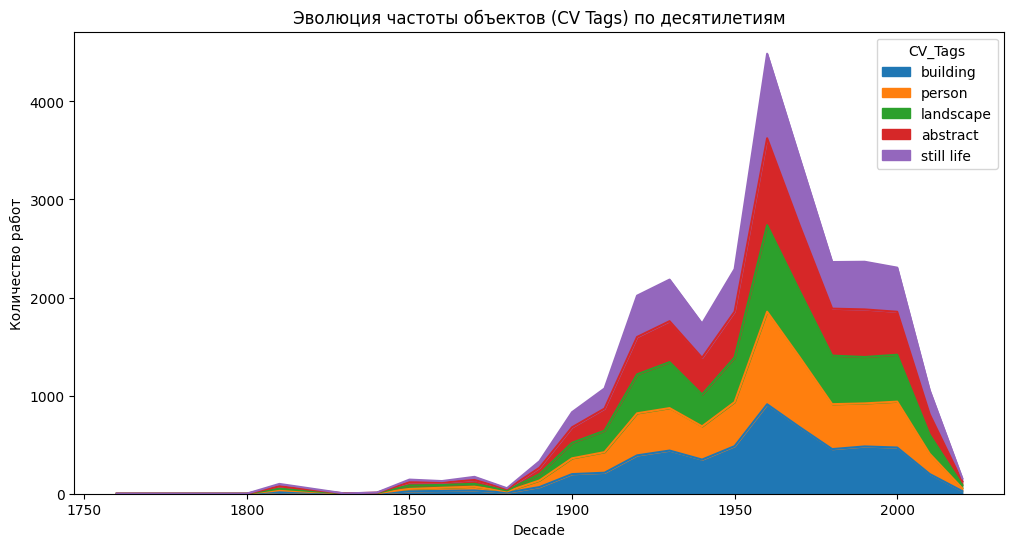

In [15]:
if not df.empty:
    print("\n--- 3.3. Детекция Объектов (Mock Logic) ---")
    # Для реальной реализации требуется загрузка изображений по ImageURL и использование библиотек CV (например, PyTorch, TensorFlow, OpenCV).
    # Здесь представлен только логический каркас.
    
    # Пример: Создание фиктивного столбца с тегами объектов
    np.random.seed(42)
    possible_tags = ['person', 'building', 'abstract', 'landscape', 'still life', 'animal']
    df['CV_Tags'] = [', '.join(np.random.choice(possible_tags, size=np.random.randint(1, 4), replace=False)) for _ in range(len(df))]
    
    # Анализ эволюции тегов во времени
    df_cv = df.dropna(subset=['Date_Created']).copy()
    df_cv['Decade'] = (df_cv['Date_Created'] // 10) * 10
    
    tag_counts = df_cv.explode('CV_Tags')['CV_Tags'].str.strip().value_counts().nlargest(5).index
    
    # Визуализация частоты тегов по десятилетиям
    tag_evolution = df_cv.explode('CV_Tags').groupby('Decade')['CV_Tags'].value_counts().unstack(fill_value=0)
    tag_evolution[tag_counts].plot(kind='area', stacked=True, figsize=(12, 6))
    plt.title('Эволюция частоты объектов (CV Tags) по десятилетиям')
    plt.ylabel('Количество работ')
    plt.show()

### 3.4. Графовый Анализ Связей в Мире Искусства (Network Analysis - Mock)


--- 3.4. Графовый Анализ (NetworkX Mock) ---
Граф создан. Узлов: 50, Ребер: 912

Топ-5 художников по степени центральности (хабы):
- Josef Albers: 1.0000
- Robert Rauschenberg: 1.0000
- Jim Dine: 1.0000
- Sol LeWitt: 0.9592
- Ben Vautier: 0.9592


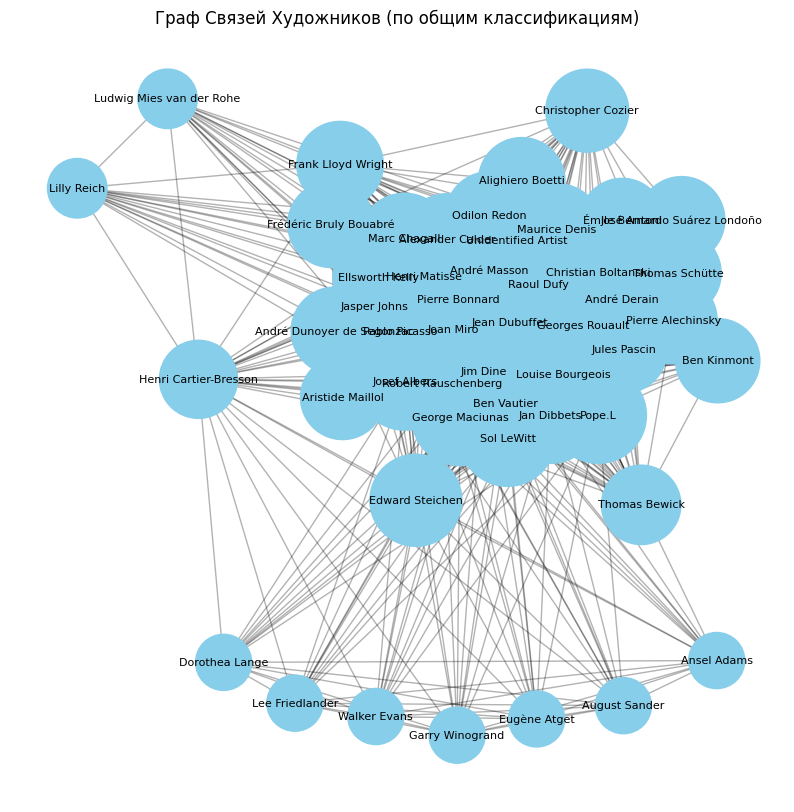

In [17]:
if not df.empty:
    print("\n--- 3.4. Графовый Анализ (NetworkX Mock) ---")
    # Создание графа на основе общих характеристик (например, одинаковая Nationality и Classification)
    
    df_graph = df.dropna(subset=['DisplayName', 'Nationality_artist', 'Classification']).copy()
    
    # Выбираем топ-50 художников для упрощения графа
    top_artists_list = df_graph['DisplayName'].value_counts().nlargest(50).index.tolist()
    df_graph = df_graph[df_graph['DisplayName'].isin(top_artists_list)]
    
    G = nx.Graph()
    
    # Добавление узлов (художников)
    artists = df_graph['DisplayName'].unique()
    G.add_nodes_from(artists)
    
    # Добавление ребер (связей)
    for i in range(len(artists)):
        for j in range(i + 1, len(artists)):
            artist1 = artists[i]
            artist2 = artists[j]
            
            # Находим общие классификации
            class1 = set(df_graph[df_graph['DisplayName'] == artist1]['Classification'].unique())
            class2 = set(df_graph[df_graph['DisplayName'] == artist2]['Classification'].unique())
            
            common_classes = len(class1.intersection(class2))
            
            if common_classes > 0:
                # Вес ребра = количество общих классификаций
                G.add_edge(artist1, artist2, weight=common_classes)
                
    print(f"Граф создан. Узлов: {G.number_of_nodes()}, Ребер: {G.number_of_edges()}")
    
    # Расчет метрик центральности
    degree_centrality = nx.degree_centrality(G)
    top_central_artists = sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True)[:5]
    
    print("\nТоп-5 художников по степени центральности (хабы):")
    for artist, centrality in top_central_artists:
        print(f"- {artist}: {centrality:.4f}")
        
    # Визуализация (упрощенная)
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, k=0.5, iterations=50)
    nx.draw_networkx_nodes(G, pos, node_size=[v * 5000 for v in degree_centrality.values()], node_color='skyblue')
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title('Граф Связей Художников (по общим классификациям)')
    plt.axis('off')
    plt.show()

### 3.5. Моделирование Вероятности Приобретения (Bayesian Inference - Mock)


--- 3.5. Доля приобретений работ женщин по десятилетиям ---
Acquisition_Decade
1920    0.000000
1930    0.027389
1940    0.080274
1950    0.056803
1960    0.024427
1970    0.118870
1980    0.111985
1990    0.251944
2000    0.225585
2010    0.270691
2020    0.273099


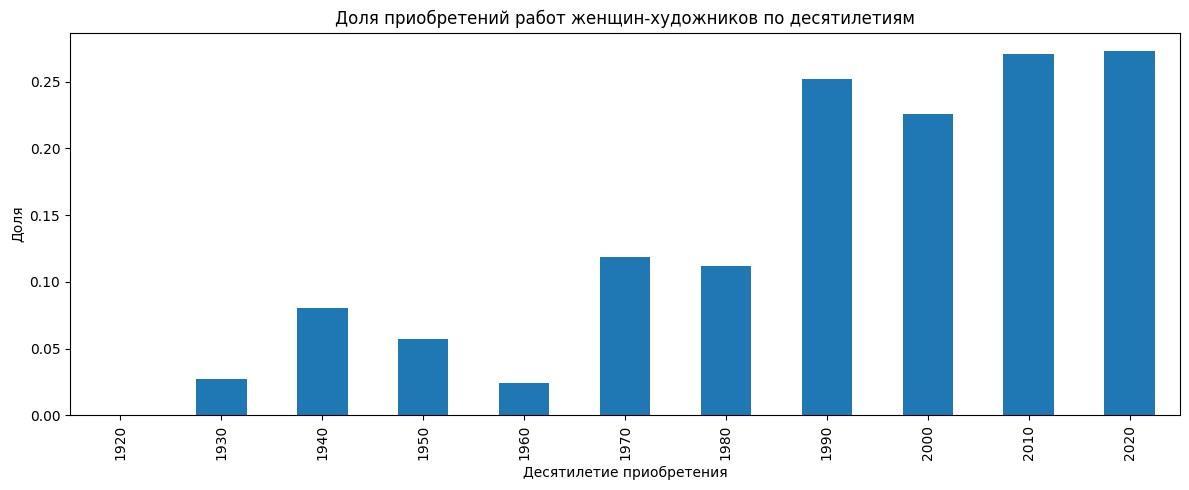

In [21]:
def normalize_gender(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"female", "f"}:
        return "Female"
    if s in {"male", "m"}:
        return "Male"
    return "Other/Unknown"

if not df.empty:
    print("\n--- 3.5. Доля приобретений работ женщин по десятилетиям ---")

    df_bayesian = df.dropna(subset=['DateAcquired', 'Gender_artist']).copy()
    df_bayesian['Gender_norm'] = df_bayesian['Gender_artist'].apply(normalize_gender)
    df_bayesian = df_bayesian.dropna(subset=['Gender_norm'])

    df_bayesian['Acquisition_Decade'] = (df_bayesian['DateAcquired'].dt.year // 10) * 10

    acquisition_pivot = (
        df_bayesian
        .groupby(['Acquisition_Decade', 'Gender_norm'])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    acquisition_pivot['Total'] = acquisition_pivot.sum(axis=1)

    # если вдруг Female всё равно отсутствует — создаём нулевую колонку
    if 'Female' not in acquisition_pivot.columns:
        acquisition_pivot['Female'] = 0

    acquisition_pivot['P(Female|Decade)'] = acquisition_pivot['Female'] / acquisition_pivot['Total'].replace(0, np.nan)

    print(acquisition_pivot['P(Female|Decade)'].dropna().to_string())

    plt.figure(figsize=(12, 5))
    acquisition_pivot['P(Female|Decade)'].dropna().plot(kind='bar')
    plt.title('Доля приобретений работ женщин-художников по десятилетиям')
    plt.ylabel('Доля')
    plt.xlabel('Десятилетие приобретения')
    plt.tight_layout()
    plt.show()

In [20]:
df.columns.to_list()

['Title',
 'Artist',
 'ConstituentID',
 'ArtistBio',
 'Nationality_work',
 'BeginDate',
 'EndDate',
 'Gender_work',
 'Date',
 'Medium',
 'Dimensions',
 'CreditLine',
 'AccessionNumber',
 'Classification',
 'Department',
 'DateAcquired',
 'Cataloged',
 'ObjectID',
 'URL',
 'ImageURL',
 'OnView',
 'Circumference (cm)',
 'Depth (cm)',
 'Diameter (cm)',
 'Height (cm)',
 'Length (cm)',
 'Weight (kg)',
 'Width (cm)',
 'Seat Height (cm)',
 'Duration (sec.)',
 'Gender_artist',
 'Nationality_artist',
 'DisplayName',
 'Date_Created',
 'Is_OnView',
 'CV_Tags']

### 3.6. Анализ Цветовой Эволюции Коллекции (CV/K-Means - Mock)


--- 3.6. Анализ Цветовой Эволюции (Mock Logic) ---


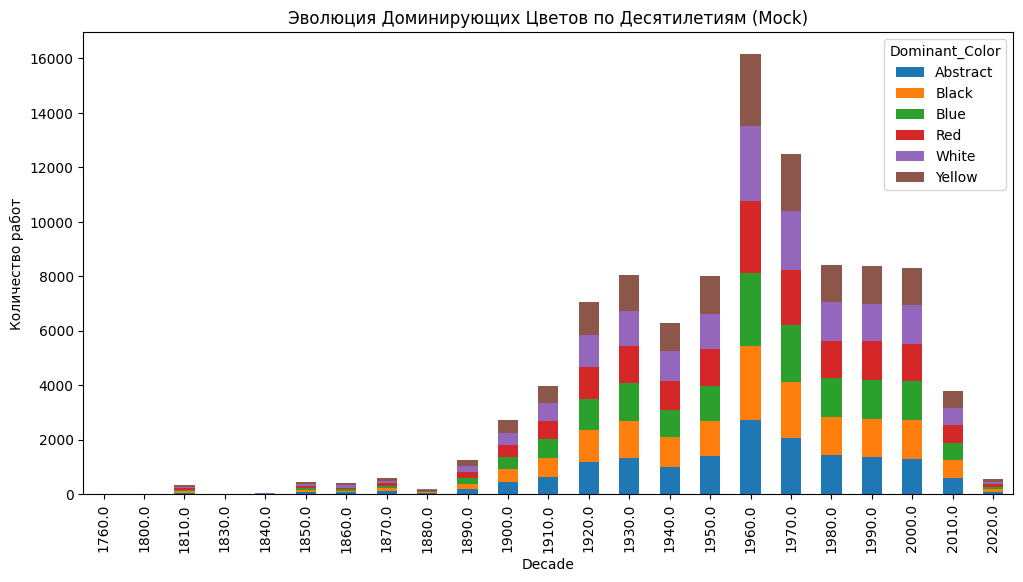

In [24]:
if not df.empty:
    print("\n--- 3.6. Анализ Цветовой Эволюции (Mock Logic) ---")
    # Для реальной реализации требуется: 
    # 1. Загрузка изображений по ImageURL.
    # 2. Использование K-Means (scikit-learn) для извлечения доминирующих цветов (например, 3-5 кластеров).
    # 3. Преобразование RGB в HSL/HSV для лучшего анализа.
    
    # Пример: Создание фиктивного столбца с доминирующим цветом
    np.random.seed(42)
    dominant_colors = ['Red', 'Blue', 'Yellow', 'Black', 'White', 'Abstract']
    df['Dominant_Color'] = np.random.choice(dominant_colors, size=len(df))
    
    df_color = df.dropna(subset=['Date_Created']).copy()
    df_color['Decade'] = (df_color['Date_Created'] // 10) * 10
    
    # Визуализация частоты доминирующих цветов по десятилетиям
    color_evolution = df_color.groupby('Decade')['Dominant_Color'].value_counts().unstack(fill_value=0)
    color_evolution.plot(kind='bar', stacked=True, figsize=(12, 6))
    plt.title('Эволюция Доминирующих Цветов по Десятилетиям (Mock)')
    plt.ylabel('Количество работ')
    plt.show()

### 3.7. Генерация Описаний и «Виртуальный Куратор» (Deep Learning - Mock)

In [25]:
if not df.empty:
    print("\n--- 3.7. Генерация Описаний (Mock Logic) ---")
    # Для реальной реализации требуется использование предобученных моделей Image-to-Text (например, BLIP, CLIP) и API.
    
    # Пример: Сравнение сгенерированного описания с реальным Title
    sample_title = df.dropna(subset=['Title']).sample(1)['Title'].iloc[0]
    
    # Имитация сгенерированного описания
    generated_description = f"A piece titled '{sample_title}' featuring elements of {np.random.choice(['modernism', 'cubism', 'abstract expressionism'])} and a dominant {np.random.choice(['red', 'blue', 'yellow'])} color palette."
    
    print(f"Оригинальное Название: {sample_title}")
    print(f"Сгенерированное Описание: {generated_description}")
    print("\n*В реальном проекте здесь будет метрика схожести (например, BLEU или ROUGE) между сгенерированным и кураторским текстом.*")


--- 3.7. Генерация Описаний (Mock Logic) ---
Оригинальное Название: The Jungle
Сгенерированное Описание: A piece titled 'The Jungle' featuring elements of cubism and a dominant blue color palette.

*В реальном проекте здесь будет метрика схожести (например, BLEU или ROUGE) между сгенерированным и кураторским текстом.*


### 3.8. Аномальный Детектив: Поиск Уникальных Работ (Isolation Forest)

In [26]:
if not df.empty:
    print("\n--- 3.8. Детекция Аномалий (Isolation Forest) ---")
    # Используем числовые параметры: размеры и даты
    features = ['Height (cm)', 'Width (cm)', 'Date_Created']
    df_anomaly = df.dropna(subset=features).copy()
    
    # Нормализация данных
    X = df_anomaly[features]
    X = (X - X.mean()) / X.std()
    
    # Обучение Isolation Forest
    # contamination - ожидаемая доля аномалий (например, 1%)
    model = IsolationForest(contamination=0.01, random_state=42)
    df_anomaly['anomaly'] = model.fit_predict(X)
    
    # Вывод топ-5 аномалий
    anomalies = df_anomaly[df_anomaly['anomaly'] == -1]
    print(f"Найдено аномалий: {len(anomalies)}")
    print("\nТоп-5 Аномальных Работ (по размерам и дате):")
    print(anomalies[['Title', 'DisplayName', 'Date_Created', 'Height (cm)', 'Width (cm)']].head().to_string())


--- 3.8. Детекция Аномалий (Isolation Forest) ---
Найдено аномалий: 841

Топ-5 Аномальных Работ (по размерам и дате):
                                                                          Title               DisplayName  Date_Created  Height (cm)  Width (cm)
198  Bismarck Monument, project, Bingen, Germany, Perspective view of courtyard  Ludwig Mies van der Rohe        1910.0     141.0000    240.0000
323                                               Endless Theatre Project, Plan         Frederick Kiesler        1924.0     210.8204    213.3604
325                                               Endless Theatre Project, Plan         Frederick Kiesler        1924.0     196.8504    213.3604
327                                            Endless Theater Project, Section         Frederick Kiesler        1924.0     118.7452    256.5405
694    Concrete Office Building Project, Berlin, Germany (Exterior perspective)  Ludwig Mies van der Rohe        1923.0     138.4000    288.9000


### 3.9. Прогнозирование Гендерного и Национального Баланса (Time Series - Mock)


--- 3.9. Кумулятивная доля Female по годам ---


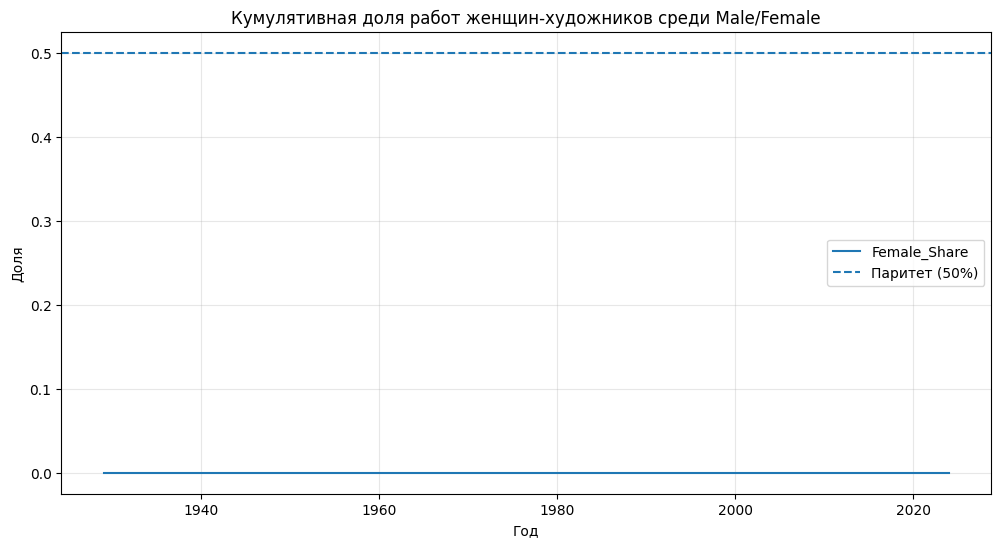

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def normalize_gender(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"male", "m"} or "male" in s:
        return "Male"
    if s in {"female", "f"} or "female" in s:
        return "Female"
    return "Other/Unknown"

if not df.empty:
    print("\n--- 3.9. Кумулятивная доля Female по годам ---")

    df_ts = df.dropna(subset=['DateAcquired', 'Gender_artist']).copy()
    df_ts['Gender'] = df_ts['Gender_artist'].apply(normalize_gender)

    df_ts = df_ts[df_ts['Gender'].isin(['Male', 'Female'])]

    df_ts['Year'] = df_ts['DateAcquired'].dt.year

    gender_counts = df_ts.groupby(['Year', 'Gender']).size().unstack(fill_value=0).sort_index()

    # на всякий случай гарантируем наличие обеих колонок
    if 'Male' not in gender_counts.columns:
        gender_counts['Male'] = 0
    if 'Female' not in gender_counts.columns:
        gender_counts['Female'] = 0

    cumulative_counts = gender_counts.cumsum()
    denom = (cumulative_counts['Female'] + cumulative_counts['Male']).replace(0, np.nan)
    cumulative_counts['Female_Share'] = cumulative_counts['Female'] / denom

    plt.figure(figsize=(12, 6))
    cumulative_counts['Female_Share'].plot()
    plt.axhline(y=0.5, linestyle='--', label='Паритет (50%)')
    plt.title('Кумулятивная доля работ женщин-художников среди Male/Female')
    plt.ylabel('Доля')
    plt.xlabel('Год')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


### 3.10. Влияние Физических Параметров на Экспозицию (Random Forest)


--- 3.10. Влияние Физических Параметров на OnView (Random Forest) ---


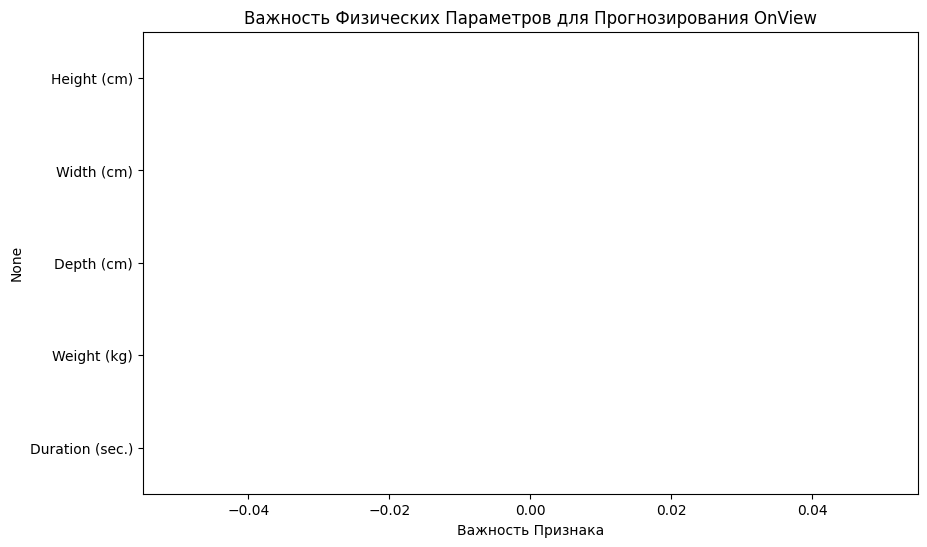

Топ-3 наиболее важных параметра:
Height (cm)    0.0
Width (cm)     0.0
Depth (cm)     0.0


In [29]:
if not df.empty:
    print("\n--- 3.10. Влияние Физических Параметров на OnView (Random Forest) ---")
    
    # Используем числовые параметры размеров
    features = ['Height (cm)', 'Width (cm)', 'Depth (cm)', 'Weight (kg)', 'Duration (sec.)']
    target = 'Is_OnView'
    
    df_rf = df.dropna(subset=features + [target]).copy()
    
    # Замена NaN в числовых столбцах медианой (если остались)
    for col in features:
        df_rf[col] = df_rf[col].fillna(df_rf[col].median())
        
    X = df_rf[features]
    y = df_rf[target]
    
    # Обучение модели Random Forest Classifier
    model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    model.fit(X, y)
    
    # Анализ важности признаков
    feature_importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances.values, y=feature_importances.index)
    plt.title('Важность Физических Параметров для Прогнозирования OnView')
    plt.xlabel('Важность Признака')
    plt.show()
    
    print("Топ-3 наиболее важных параметра:")
    print(feature_importances.head(3).to_string())

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def normalize_gender(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"male", "m"} or "male" in s:
        return "Male"
    if s in {"female", "f"} or "female" in s:
        return "Female"
    return "Other/Unknown"

def safe_to_year(s):
    return pd.to_numeric(s, errors="coerce")

df_base = df.copy()

# гарантируем DateAcquired datetime
df_base["DateAcquired"] = pd.to_datetime(df_base.get("DateAcquired"), errors="coerce")

# нормализуем гендер/нац (берём artist)
df_base["Gender_norm"] = df_base.get("Gender_artist").apply(normalize_gender) if "Gender_artist" in df_base.columns else np.nan
df_base["Nationality_norm"] = df_base.get("Nationality_artist").astype(str).str.strip() if "Nationality_artist" in df_base.columns else np.nan

# годы/десятилетия приобретения
df_base["Acq_Year"] = df_base["DateAcquired"].dt.year
df_base["Acq_Decade"] = (df_base["Acq_Year"] // 10) * 10

# год создания
if "Date_Created" in df_base.columns:
    df_base["Created_Year"] = safe_to_year(df_base["Date_Created"])
elif "Date" in df_base.columns:
    df_base["Created_Year"] = safe_to_year(df_base["Date"])
else:
    df_base["Created_Year"] = np.nan

# лаг создание->покупка
df_base["Lag_Years"] = df_base["Acq_Year"] - df_base["Created_Year"]

# Is_OnView в int {0,1}
if "Is_OnView" in df_base.columns:
    df_base["Is_OnView"] = pd.to_numeric(df_base["Is_OnView"], errors="coerce").fillna(0).astype(int)

print("df_base shape:", df_base.shape)
print("cols check:", [c for c in ["DateAcquired","Is_OnView","Gender_norm","Nationality_norm","Acq_Year","Acq_Decade","Created_Year","Lag_Years"] if c in df_base.columns])


df_base shape: (157630, 43)
cols check: ['DateAcquired', 'Is_OnView', 'Gender_norm', 'Nationality_norm', 'Acq_Year', 'Acq_Decade', 'Created_Year', 'Lag_Years']


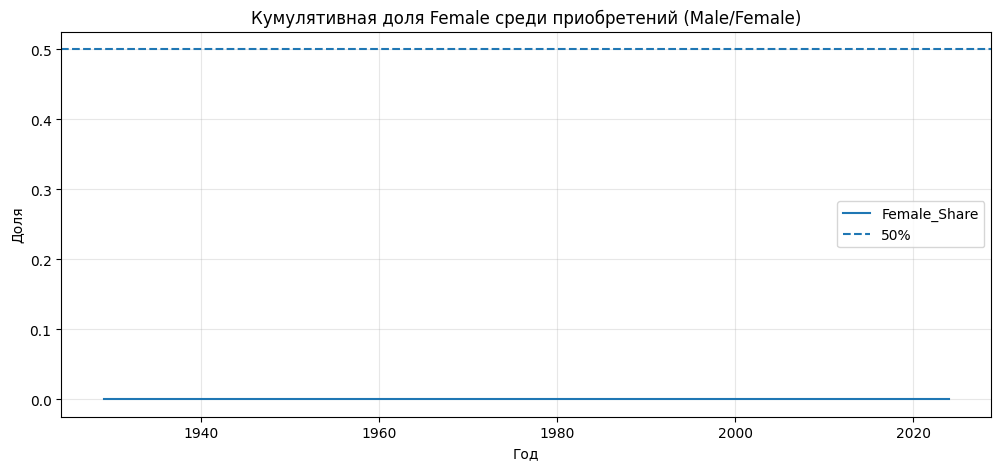

In [31]:
ts = df_base.dropna(subset=["Acq_Year", "Gender_norm"]).copy()
ts = ts[ts["Gender_norm"].isin(["Male","Female"])]

gender_year = ts.groupby(["Acq_Year","Gender_norm"]).size().unstack(fill_value=0).sort_index()
if "Male" not in gender_year.columns: gender_year["Male"] = 0
if "Female" not in gender_year.columns: gender_year["Female"] = 0

cum = gender_year.cumsum()
cum["Female_Share"] = cum["Female"] / (cum["Female"] + cum["Male"]).replace(0, np.nan)

plt.figure(figsize=(12,5))
cum["Female_Share"].plot()
plt.axhline(0.5, linestyle="--", label="50%")
plt.title("Кумулятивная доля Female среди приобретений (Male/Female)")
plt.xlabel("Год")
plt.ylabel("Доля")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


ruptures не доступен или упал, fallback rolling z-score. Причина: No module named 'ruptures'
Возможные переломы (|z|>2.5): []


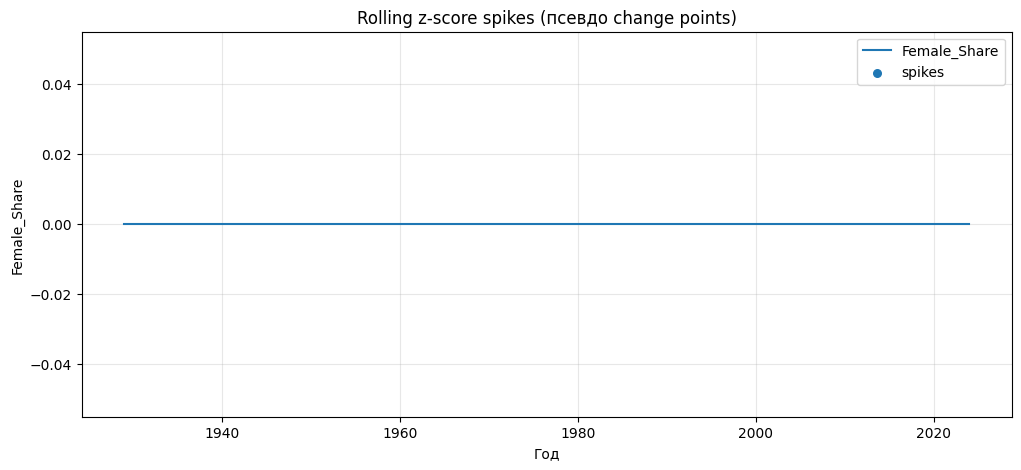

In [32]:
y = cum["Female_Share"].dropna()
years = y.index.values

try:
    import ruptures as rpt
    signal = y.values.astype(float)
    algo = rpt.Pelt(model="rbf").fit(signal)
    bkps = algo.predict(pen=3)  # можно крутить 2..10
    cp_years = [years[i-1] for i in bkps if i-1 < len(years)]
    print("Change points years:", cp_years)

    plt.figure(figsize=(12,5))
    plt.plot(years, y.values)
    for cp in cp_years:
        plt.axvline(cp, linestyle="--", alpha=0.7)
    plt.title("Change points (ruptures) по Female_Share")
    plt.xlabel("Год"); plt.ylabel("Female_Share")
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print("ruptures не доступен или упал, fallback rolling z-score. Причина:", e)

    roll = y.rolling(10, min_periods=8)
    z = (y - roll.mean()) / roll.std()
    spikes = z[abs(z) > 2.5]
    print("Возможные переломы (|z|>2.5):", list(spikes.index[:20]))

    plt.figure(figsize=(12,5))
    plt.plot(years, y.values, label="Female_Share")
    plt.scatter(spikes.index, y.loc[spikes.index], label="spikes", s=30)
    plt.title("Rolling z-score spikes (псевдо change points)")
    plt.xlabel("Год"); plt.ylabel("Female_Share")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


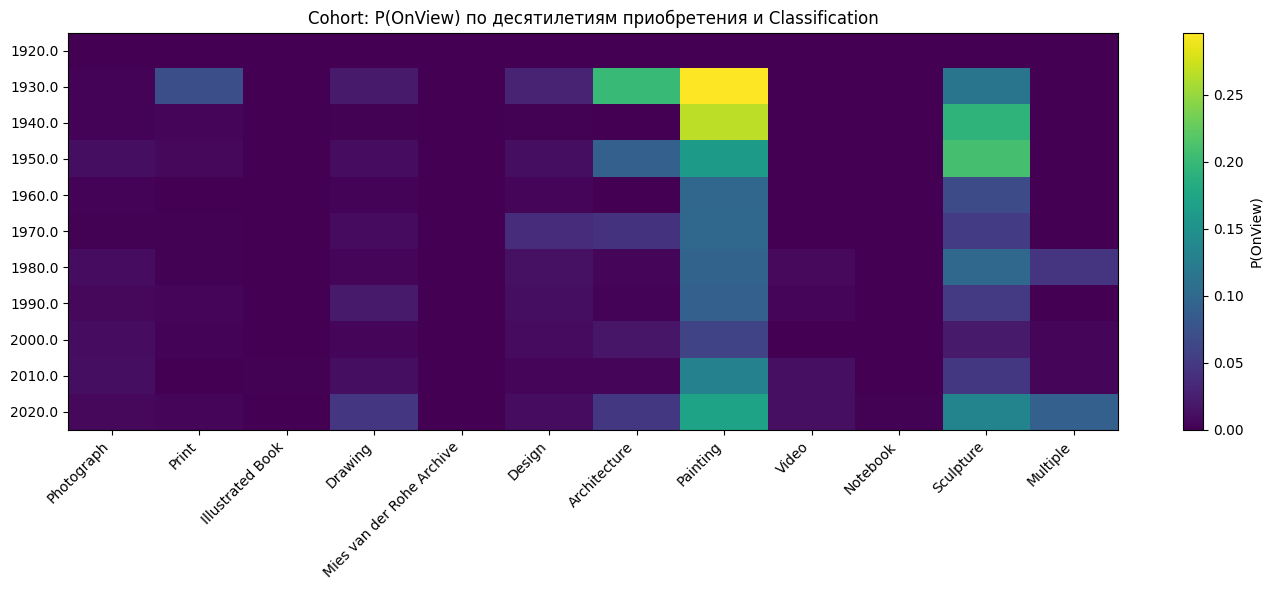

In [33]:
co = df_base.dropna(subset=["Acq_Decade","Classification","Is_OnView"]).copy()

pivot = co.pivot_table(
    index="Acq_Decade",
    columns="Classification",
    values="Is_OnView",
    aggfunc="mean"
).sort_index()

# оставим топ-12 classification по частоте
top_cls = co["Classification"].value_counts().head(12).index
pivot = pivot[top_cls]

plt.figure(figsize=(14,6))
plt.imshow(pivot.fillna(0).values, aspect="auto")
plt.colorbar(label="P(OnView)")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
plt.title("Cohort: P(OnView) по десятилетиям приобретения и Classification")
plt.tight_layout()
plt.show()


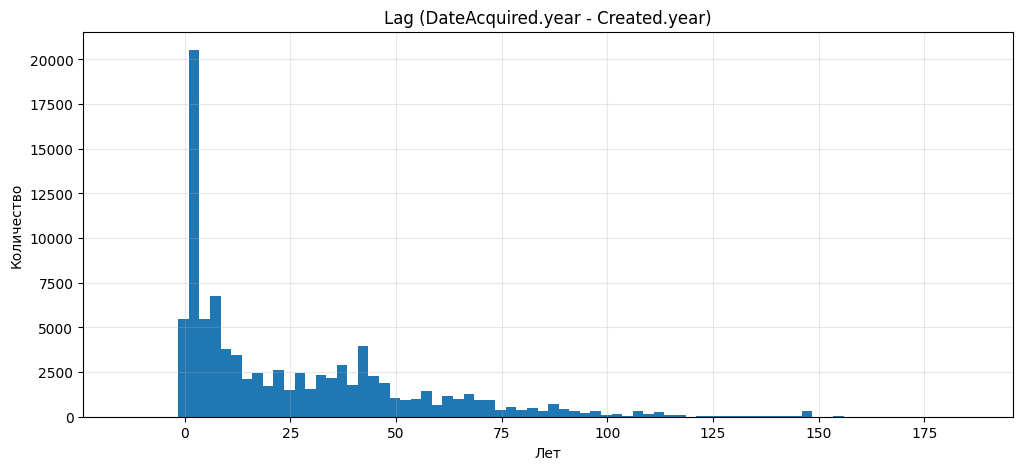

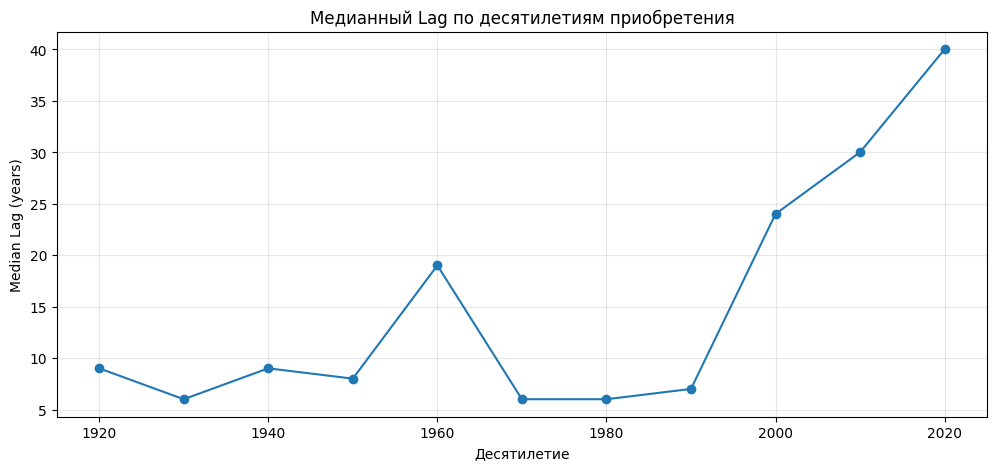

C:\Users\Shaim\AppData\Local\Temp\ipykernel_31108\211491053.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=["Male","Female"], showfliers=False)


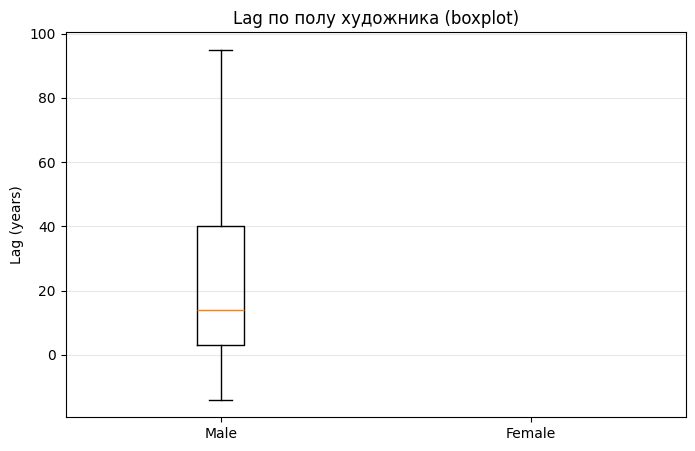

In [34]:
lag = df_base.dropna(subset=["Lag_Years"]).copy()
lag = lag[(lag["Lag_Years"].between(-50, 300))]  # грубый фильтр от мусора, можно расширить

plt.figure(figsize=(12,5))
plt.hist(lag["Lag_Years"].dropna(), bins=80)
plt.title("Lag (DateAcquired.year - Created.year)")
plt.xlabel("Лет")
plt.ylabel("Количество")
plt.grid(True, alpha=0.3)
plt.show()

# lag по десятилетиям
lag_dec = lag.dropna(subset=["Acq_Decade"]).copy()
grp = lag_dec.groupby("Acq_Decade")["Lag_Years"].median().sort_index()

plt.figure(figsize=(12,5))
grp.plot(kind="line", marker="o")
plt.title("Медианный Lag по десятилетиям приобретения")
plt.xlabel("Десятилетие")
plt.ylabel("Median Lag (years)")
plt.grid(True, alpha=0.3)
plt.show()

# lag по полу (Male/Female)
lag_g = lag_dec[lag_dec["Gender_norm"].isin(["Male","Female"])].copy()
box_data = [lag_g.loc[lag_g["Gender_norm"]==g, "Lag_Years"].dropna().values for g in ["Male","Female"]]

plt.figure(figsize=(8,5))
plt.boxplot(box_data, labels=["Male","Female"], showfliers=False)
plt.title("Lag по полу художника (boxplot)")
plt.ylabel("Lag (years)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

txt = df_base.dropna(subset=["Medium","Is_OnView"]).copy()
txt["Medium"] = txt["Medium"].astype(str).str.lower()

X_train, X_test, y_train, y_test = train_test_split(
    txt["Medium"], txt["Is_OnView"], test_size=0.25, random_state=42, stratify=txt["Is_OnView"]
)

vec = TfidfVectorizer(min_df=30, ngram_range=(1,2), stop_words="english")
Xtr = vec.fit_transform(X_train)
Xte = vec.transform(X_test)

clf = LogisticRegression(max_iter=2000, n_jobs=None)
clf.fit(Xtr, y_train)

pred = clf.predict_proba(Xte)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, pred))

# топ-токены
feature_names = np.array(vec.get_feature_names_out())
coef = clf.coef_[0]
top_pos = feature_names[np.argsort(coef)[-20:]][::-1]
top_neg = feature_names[np.argsort(coef)[:20]]

print("\nTop tokens increasing OnView:")
print(top_pos)
print("\nTop tokens decreasing OnView:")
print(top_neg)


ROC-AUC: 0.8686752801667226

Top tokens increasing OnView:
['casein' 'bronze' 'painted' 'blown' 'rubbings' 'enamel' 'ink gouache'
 'oil' 'print printed' 'pochoirs' 'tempera' 'ink colored' 'canvas'
 'colored paper' 'metal' 'digital photograph' 'acrylic' 'etched' 'pochoir'
 'paint']

Top tokens decreasing OnView:
['book' 'pencil' 'black' 'print' 'color' 'illustrated' 'illustrated book'
 'printed black' 'engraving' 'lithograph' 'poster' 'etchings' 'tracing'
 'printed color' 'offset' 'chromogenic print' 'lithographs' 'chromogenic'
 'etching' 'tracing paper']


Artists in profile: 2500 | min works: 5
Graph nodes: 2500 edges: 8733

Top degree centrality:
4913 0.0088 | James Riddle
21398 0.0076 | George Maciunas
5661 0.0068 | Rex A. Stevens
7502 0.0064 | Rebecca Horn
6015 0.0064 | Unidentified Designer
1652 0.0060 | Carroll Dunham
198 0.0060 | Garo Antreasian
2281 0.0060 | Dan Graham
7041 0.0060 | Madoka Takagi
26465 0.0060 | Josiah McElheny


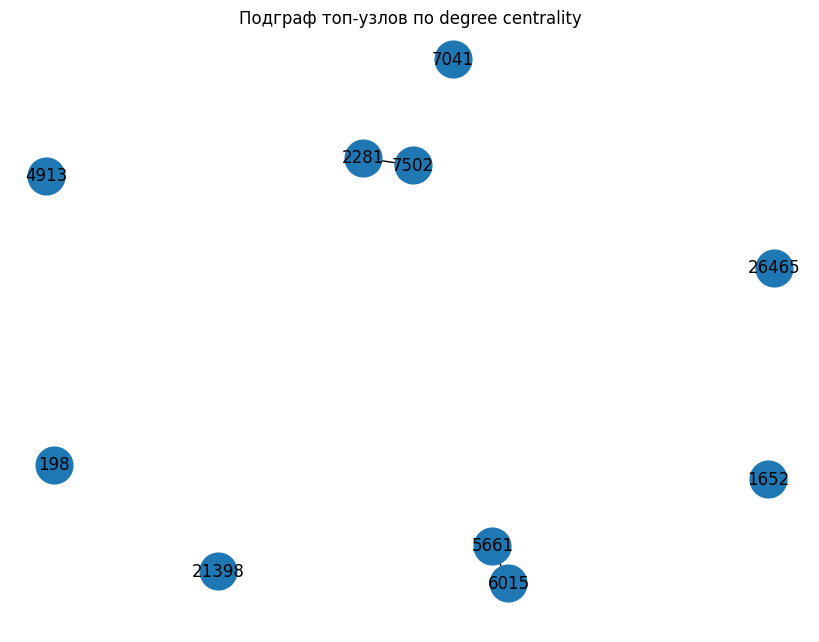

In [41]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity  # не обязателен теперь

def parse_year(x):
    """Достаёт первый год из строки: '(1930)' -> 1930, '1930-1940' -> 1930, иначе NaN"""
    if pd.isna(x):
        return np.nan
    s = str(x)
    m = re.search(r"(-?\d{3,4})", s)
    return float(m.group(1)) if m else np.nan

# --- настройки ---
MIN_WORKS = 5          # минимум работ на художника, чтобы попасть в граф
MAX_ARTISTS = 2500     # ограничение по числу художников (чтобы не улететь по памяти/времени)
TOP_K = 5              # сколько соседей добавлять
SIM_THRESH = 0.60      # порог похожести (cosine similarity)

if "ConstituentID" not in df_base.columns:
    raise KeyError("Нет ConstituentID в df_base")

a = df_base.dropna(subset=["ConstituentID"]).copy()
a["ConstituentID"] = pd.to_numeric(a["ConstituentID"], errors="coerce")
a = a.dropna(subset=["ConstituentID"])
a["ConstituentID"] = a["ConstituentID"].astype(int)

# парсим года рождения/смерти (или активные годы)
if "BeginDate" in a.columns:
    a["BeginYear"] = a["BeginDate"].apply(parse_year)
else:
    a["BeginYear"] = np.nan

if "EndDate" in a.columns:
    a["EndYear"] = a["EndDate"].apply(parse_year)
else:
    a["EndYear"] = np.nan

# профиль художника
prof = a.groupby("ConstituentID").agg(
    Nationality=("Nationality_artist", lambda x: x.dropna().astype(str).value_counts().index[0] if len(x.dropna()) else "Unknown"),
    Classification=("Classification", lambda x: x.dropna().astype(str).value_counts().index[0] if len(x.dropna()) else "Unknown"),
    Begin=("BeginYear", "median"),
    End=("EndYear", "median"),
    Works=("ObjectID", "count") if "ObjectID" in a.columns else ("Title", "count")
).reset_index()

prof = prof[prof["Works"] >= MIN_WORKS].copy()
prof = prof.sort_values("Works", ascending=False)

# ограничим размер (если много)
if len(prof) > MAX_ARTISTS:
    prof = prof.head(MAX_ARTISTS).copy()

print("Artists in profile:", len(prof), "| min works:", MIN_WORKS)

# признаки
cat = pd.get_dummies(prof[["Nationality", "Classification"]], drop_first=True)

# числовые признаки: Begin/End
num = prof[["Begin", "End"]].copy()
num = num.fillna(num.median(numeric_only=True))

X_prof = pd.concat([cat, num], axis=1).fillna(0)

# Nearest Neighbors по cosine distance
nn = NearestNeighbors(n_neighbors=min(TOP_K + 1, len(prof)), metric="cosine", algorithm="auto")
nn.fit(X_prof.values)

dist, ind = nn.kneighbors(X_prof.values, return_distance=True)
# cosine similarity = 1 - distance
sim = 1 - dist

ids = prof["ConstituentID"].values.astype(int)
works_map = dict(zip(ids, prof["Works"].astype(int).values))

# граф
G = nx.Graph()
for cid in ids:
    G.add_node(int(cid), works=int(works_map[int(cid)]))

for i in range(len(ids)):
    src = int(ids[i])
    for k in range(1, ind.shape[1]):  # 0-й сосед = сам объект
        j = ind[i, k]
        dst = int(ids[j])
        s = float(sim[i, k])
        if s >= SIM_THRESH and src != dst:
            G.add_edge(src, dst, weight=s)

print("Graph nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

# центральности
deg = nx.degree_centrality(G)
top_deg = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:10]

# добавим имена, если есть DisplayName
name_map = None
if "DisplayName" in df_base.columns:
    tmp = df_base.dropna(subset=["ConstituentID","DisplayName"]).copy()
    tmp["ConstituentID"] = pd.to_numeric(tmp["ConstituentID"], errors="coerce")
    tmp = tmp.dropna(subset=["ConstituentID"])
    tmp["ConstituentID"] = tmp["ConstituentID"].astype(int)
    name_map = tmp.groupby("ConstituentID")["DisplayName"].agg(lambda x: x.value_counts().index[0]).to_dict()

print("\nTop degree centrality:")
for cid, score in top_deg:
    nm = name_map.get(cid, "") if name_map else ""
    print(cid, f"{score:.4f}", ("| " + nm) if nm else "")

# визуализация подграфа
top_nodes = [n for n,_ in top_deg]
H = G.subgraph(top_nodes).copy()

plt.figure(figsize=(8,6))
pos = nx.spring_layout(H, seed=42)
nx.draw(H, pos, with_labels=True, node_size=700)
plt.title("Подграф топ-узлов по degree centrality")
plt.show()


Size cols: ['Height (cm)', 'Width (cm)', 'Depth (cm)', 'Weight (kg)', 'Duration (sec.)']


C:\Users\Shaim\AppData\Local\Temp\ipykernel_31108\3714461171.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stat = tmp.groupby("bin")["Is_OnView"].mean()


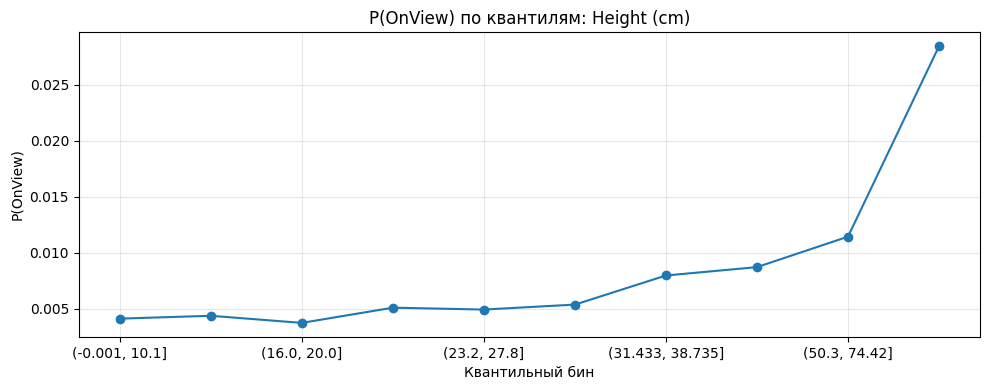


Height (cm): средняя P(OnView)=0.008. Бины выше среднего:
bin
(38.735, 50.3]     0.008708
(50.3, 74.42]      0.011430
(74.42, 9140.0]    0.028467
Name: Is_OnView, dtype: float64


C:\Users\Shaim\AppData\Local\Temp\ipykernel_31108\3714461171.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stat = tmp.groupby("bin")["Is_OnView"].mean()


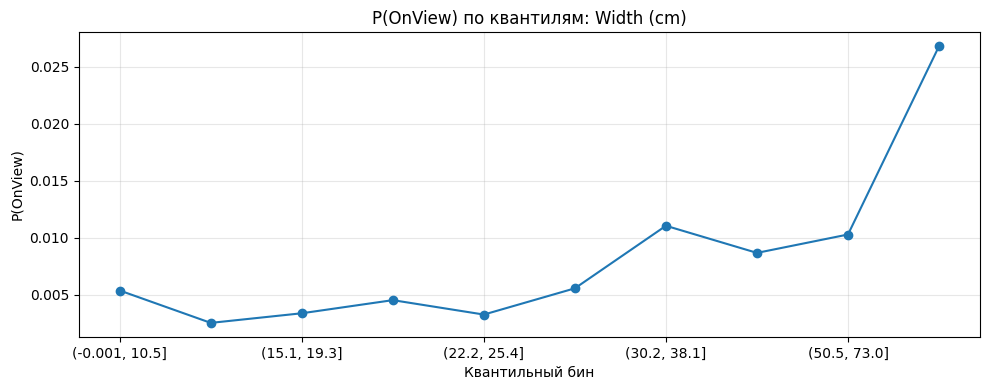


Width (cm): средняя P(OnView)=0.008. Бины выше среднего:
bin
(30.2, 38.1]      0.011058
(38.1, 50.5]      0.008679
(50.5, 73.0]      0.010292
(73.0, 9144.0]    0.026823
Name: Is_OnView, dtype: float64


In [37]:
size_cols = [c for c in ["Height (cm)","Width (cm)","Depth (cm)","Weight (kg)","Duration (sec.)"] if c in df_base.columns]
print("Size cols:", size_cols)

d = df_base.dropna(subset=["Is_OnView"]).copy()

for col in ["Height (cm)", "Width (cm)"]:
    if col not in d.columns: 
        continue

    s = pd.to_numeric(d[col], errors="coerce")
    tmp = d.loc[s.notna(), ["Is_OnView"]].copy()
    tmp[col] = s[s.notna()]

    # биним по квантилям
    tmp["bin"] = pd.qcut(tmp[col], q=10, duplicates="drop")
    stat = tmp.groupby("bin")["Is_OnView"].mean()

    plt.figure(figsize=(10,4))
    stat.plot(kind="line", marker="o")
    plt.title(f"P(OnView) по квантилям: {col}")
    plt.ylabel("P(OnView)")
    plt.xlabel("Квантильный бин")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # "идеальные" бины
    med = tmp["Is_OnView"].mean()
    good = stat[stat > med]
    print(f"\n{col}: средняя P(OnView)={med:.3f}. Бины выше среднего:")
    print(good)


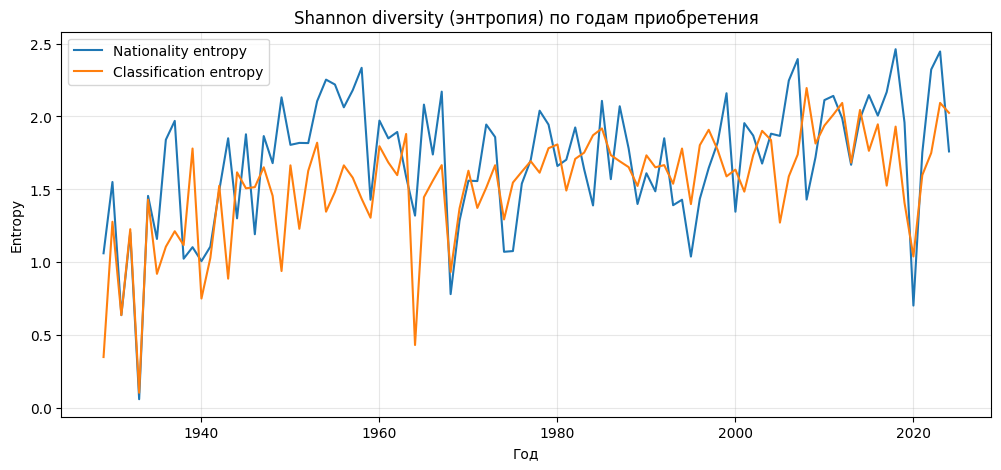

In [38]:
def shannon_entropy(series):
    vc = series.dropna().astype(str).value_counts()
    p = vc / vc.sum()
    return float(-(p * np.log(p)).sum())

ent = df_base.dropna(subset=["Acq_Year"]).copy()

# ограничим категории, чтобы "Unknown" не доминировал мусором
ent["Nat"] = ent["Nationality_norm"].replace({"nan": np.nan, "None": np.nan})
ent["Cls"] = ent["Classification"] if "Classification" in ent.columns else np.nan

by_year = ent.groupby("Acq_Year").agg(
    H_Nationality=("Nat", shannon_entropy),
    H_Classification=("Cls", shannon_entropy),
    N=("ObjectID","count") if "ObjectID" in ent.columns else ("Title","count")
).sort_index()

plt.figure(figsize=(12,5))
by_year["H_Nationality"].plot(label="Nationality entropy")
by_year["H_Classification"].plot(label="Classification entropy")
plt.title("Shannon diversity (энтропия) по годам приобретения")
plt.xlabel("Год")
plt.ylabel("Entropy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Gini (works per artist): 0.8362565237952269


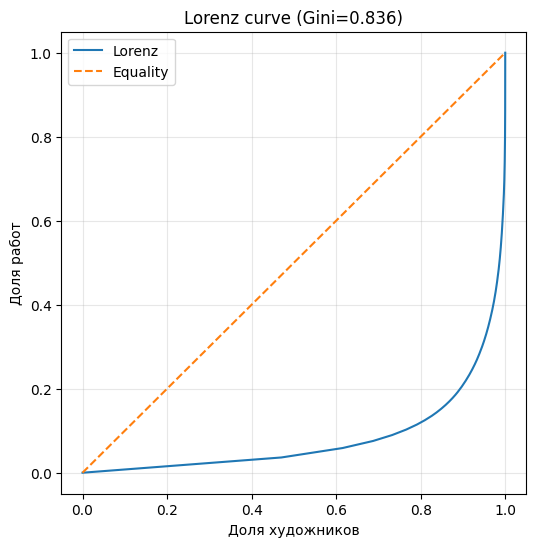

Top 1% artists hold ~ 45.57% of works
Top 5% artists hold ~ 68.57% of works
Top 10% artists hold ~ 79.07% of works


In [39]:
if "ConstituentID" not in df_base.columns:
    raise KeyError("Нет ConstituentID")

cnt = df_base.dropna(subset=["ConstituentID"]).copy()
cnt["ConstituentID"] = pd.to_numeric(cnt["ConstituentID"], errors="coerce").astype("Int64")
cnt = cnt.dropna(subset=["ConstituentID"])

works = cnt.groupby("ConstituentID").size().sort_values(ascending=True).values.astype(float)

def gini(x):
    x = np.sort(x)
    n = len(x)
    if n == 0: return np.nan
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

G = gini(works)
print("Gini (works per artist):", G)

# Lorenz
x = np.sort(works)
cum = np.cumsum(x) / np.sum(x)
pop = np.arange(1, len(x)+1) / len(x)

plt.figure(figsize=(6,6))
plt.plot(pop, cum, label="Lorenz")
plt.plot([0,1],[0,1], linestyle="--", label="Equality")
plt.title(f"Lorenz curve (Gini={G:.3f})")
plt.xlabel("Доля художников")
plt.ylabel("Доля работ")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Pareto: доля работ у топ-1%, 5%, 10%
desc = np.sort(works)[::-1]
cum_desc = np.cumsum(desc) / np.sum(desc)
for p in [0.01, 0.05, 0.10]:
    k = max(1, int(len(desc)*p))
    share = cum_desc[k-1]
    print(f"Top {int(p*100)}% artists hold ~ {share:.2%} of works")


LOGREG ROC-AUC: 0.9085005467923007 PR-AUC: 0.14634846981953906
RF     ROC-AUC: 0.9154677245968591 PR-AUC: 0.2628128119022115

Top-20 permutation importance (RF):
Depth (cm)                   0.000010
Duration (sec.)              0.000000
Weight (kg)                  0.000000
Gender_norm_Male             0.000000
Lag_Years                   -0.001690
Nationality_norm_Algerian   -0.001817
Created_Year                -0.001822
Width (cm)                  -0.001832
Height (cm)                 -0.001852
Nationality_norm_American   -0.001878
Nationality_norm_Albanian   -0.002101
Gender_norm_Other/Unknown   -0.002167
Acq_Year                    -0.002598
dtype: float64


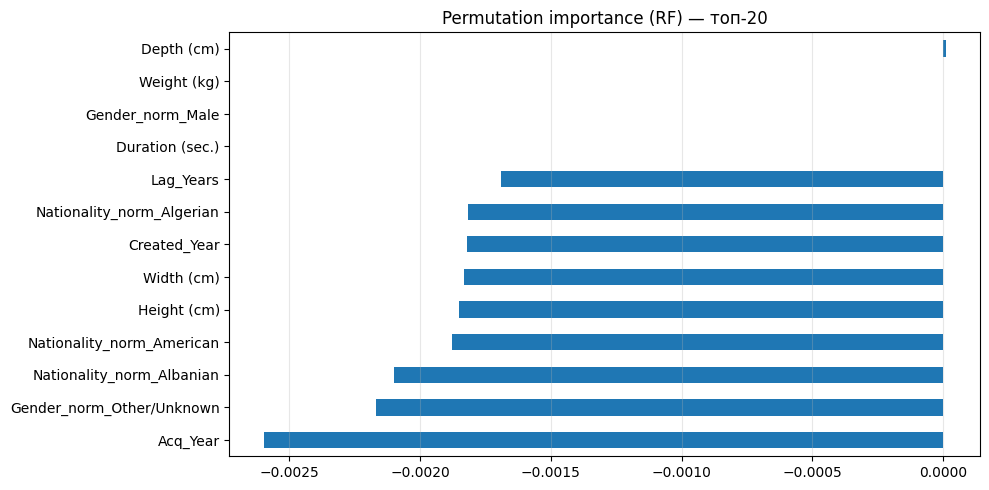

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_extraction.text import TfidfVectorizer

# --- маленький трансформер, который превращает NaN -> "" и приводит к str ---
class TextCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        # X приходит как DataFrame/Series/ndarray
        if isinstance(X, pd.DataFrame):
            s = X.iloc[:, 0]
        elif isinstance(X, pd.Series):
            s = X
        else:
            s = pd.Series(X.ravel())
        return s.fillna("").astype(str).values

# собираем фичи
target = "Is_OnView"
feat_num = [c for c in ["Lag_Years","Created_Year","Acq_Year","Height (cm)","Width (cm)","Depth (cm)","Weight (kg)","Duration (sec.)"] if c in df_base.columns]
feat_cat = [c for c in ["Gender_norm","Nationality_norm","Classification","Department"] if c in df_base.columns]
feat_txt = "Medium" if "Medium" in df_base.columns else None

ml = df_base.dropna(subset=[target]).copy()

# грубый фильтр лагов от мусора
if "Lag_Years" in ml.columns:
    ml.loc[~ml["Lag_Years"].between(-50, 300), "Lag_Years"] = np.nan

# X / y
use_cols = feat_num + feat_cat + ([feat_txt] if feat_txt else [])
X = ml[use_cols].copy()
y = ml[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

num_pipe = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
])

cat_pipe = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

transformers = []
if feat_num:
    transformers.append(("num", num_pipe, feat_num))
if feat_cat:
    transformers.append(("cat", cat_pipe, feat_cat))
if feat_txt:
    txt_pipe = Pipeline(steps=[
        ("clean", TextCleaner()),
        ("tfidf", TfidfVectorizer(min_df=30, ngram_range=(1,2), stop_words="english"))
    ])
    transformers.append(("txt", txt_pipe, [feat_txt]))  # важно: список колонок

pre = ColumnTransformer(transformers=transformers, remainder="drop")

# 10A) Logistic Regression
logreg = Pipeline(steps=[
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=2000))
])

logreg.fit(X_train, y_train)
p = logreg.predict_proba(X_test)[:, 1]
print("LOGREG ROC-AUC:", roc_auc_score(y_test, p), "PR-AUC:", average_precision_score(y_test, p))

# 10B) Random Forest
rf = Pipeline(steps=[
    ("pre", pre),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced"))
])

rf.fit(X_train, y_train)
p2 = rf.predict_proba(X_test)[:, 1]
print("RF     ROC-AUC:", roc_auc_score(y_test, p2), "PR-AUC:", average_precision_score(y_test, p2))

# 10C) Permutation importance (лучше на RF)
try:
    r = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
    imp = r.importances_mean
    order = np.argsort(imp)[::-1][:20]

    # восстановим имена фич
    feature_names = []
    pre_fitted = rf.named_steps["pre"]

    for name, trans, cols in pre_fitted.transformers_:
        if name == "num":
            feature_names.extend(cols)
        elif name == "cat":
            ohe = trans.named_steps["ohe"]
            feature_names.extend(list(ohe.get_feature_names_out(cols)))
        elif name == "txt":
            # txt_pipe = Pipeline(clean -> tfidf)
            vec = trans.named_steps["tfidf"]
            feature_names.extend([f"tfidf:{t}" for t in vec.get_feature_names_out()])

    feature_names = np.array(feature_names)
    top = pd.Series(imp[order], index=feature_names[order])

    print("\nTop-20 permutation importance (RF):")
    print(top)

    plt.figure(figsize=(10, 5))
    top.sort_values().plot(kind="barh")
    plt.title("Permutation importance (RF) — топ-20")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Permutation importance не получилось:", e)


In [43]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

df = df_base.copy()

def parse_year(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    m = re.search(r"(-?\d{3,4})", s)
    return float(m.group(1)) if m else np.nan

def normalize_gender(x):
    if pd.isna(x):
        return "Other/Unknown"
    s = str(x).strip().lower()
    if s in {"male","m"}:
        return "Male"
    if s in {"female","f"}:
        return "Female"
    return "Other/Unknown"

def normalize_nat(x):
    if pd.isna(x):
        return "Unknown"
    s = str(x).strip()
    return s if s else "Unknown"

# даты
if "DateAcquired" in df.columns:
    df["DateAcquired"] = pd.to_datetime(df["DateAcquired"], errors="coerce")

# Is_OnView
if "Is_OnView" not in df.columns:
    if "OnView" in df.columns:
        df["Is_OnView"] = (df["OnView"].astype(str).str.upper() == "Y").astype(int)
    else:
        df["Is_OnView"] = np.nan

# Acq_Year
if "Acq_Year" not in df.columns:
    df["Acq_Year"] = df["DateAcquired"].dt.year

# Created_Year
if "Created_Year" not in df.columns:
    if "Date_Created" in df.columns:
        df["Created_Year"] = pd.to_numeric(df["Date_Created"], errors="coerce")
    elif "Date" in df.columns:
        df["Created_Year"] = df["Date"].apply(parse_year)
    else:
        df["Created_Year"] = np.nan

# Lag_Years = покупка - создание
if "Lag_Years" not in df.columns:
    df["Lag_Years"] = df["Acq_Year"] - df["Created_Year"]

# Gender_norm / Nationality_norm
if "Gender_norm" not in df.columns:
    src = "Gender_artist" if "Gender_artist" in df.columns else ("Gender" if "Gender" in df.columns else None)
    df["Gender_norm"] = df[src].apply(normalize_gender) if src else "Other/Unknown"

if "Nationality_norm" not in df.columns:
    src = "Nationality_artist" if "Nationality_artist" in df.columns else ("Nationality" if "Nationality" in df.columns else None)
    df["Nationality_norm"] = df[src].apply(normalize_nat) if src else "Unknown"

# Artist id
if "ConstituentID" in df.columns:
    df["ConstituentID"] = pd.to_numeric(df["ConstituentID"], errors="coerce").astype("Int64")

print("rows:", len(df), "| cols:", len(df.columns))
print("has:", {c: (c in df.columns) for c in ["Is_OnView","DateAcquired","Acq_Year","Created_Year","Lag_Years","Gender_norm","Nationality_norm","Department","Classification","Medium","Title","ConstituentID"]})


rows: 157630 | cols: 43
has: {'Is_OnView': True, 'DateAcquired': True, 'Acq_Year': True, 'Created_Year': True, 'Lag_Years': True, 'Gender_norm': True, 'Nationality_norm': True, 'Department': True, 'Classification': True, 'Medium': True, 'Title': True, 'ConstituentID': True}


C:\Users\Shaim\AppData\Local\Temp\ipykernel_31108\3034618280.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = d.groupby("bin").agg(


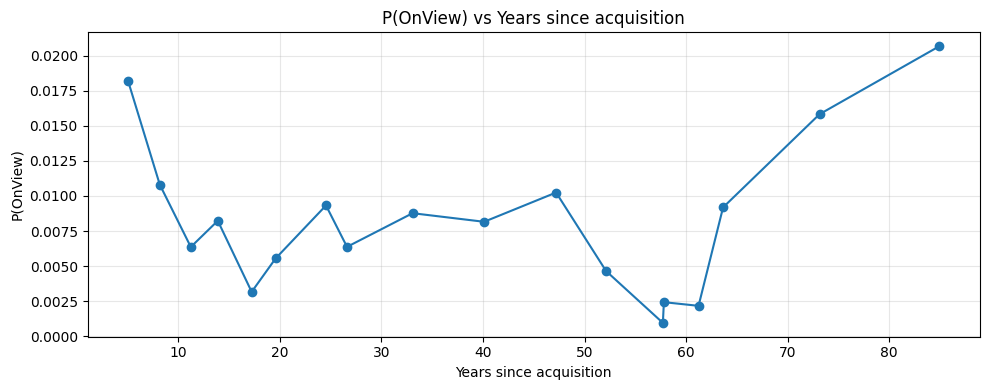

,bin,n,p_onview,x_mid
0,"(1.163, 6.146]",7582,0.018201,5.048597
1,"(6.146, 10.168]",7680,0.010807,8.169747
2,"(10.168, 12.214]",7390,0.006360,11.225188
3,"(12.214, 15.222]",7775,0.008232,13.880903
4,"(15.222, 17.218]",7912,0.003160,17.218344


In [44]:
d = df.dropna(subset=["DateAcquired","Is_OnView"]).copy()
today = pd.Timestamp(datetime.now())
d["Years_Since_Acq"] = (today - d["DateAcquired"]).dt.days / 365.25
d = d[(d["Years_Since_Acq"] >= 0) & np.isfinite(d["Years_Since_Acq"])]

# биннинг (квантили, чтобы в каждом бине было похоже по размеру)
bins = 20
d["bin"] = pd.qcut(d["Years_Since_Acq"], q=bins, duplicates="drop")

g = d.groupby("bin").agg(
    n=("Is_OnView","size"),
    p_onview=("Is_OnView","mean"),
    x_mid=("Years_Since_Acq","median")
).reset_index().sort_values("x_mid")

plt.figure(figsize=(10,4))
plt.plot(g["x_mid"], g["p_onview"], marker="o")
plt.title("P(OnView) vs Years since acquisition")
plt.xlabel("Years since acquisition")
plt.ylabel("P(OnView)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

g.head()


In [45]:
d = df.dropna(subset=["Department","Is_OnView"]).copy()

def shannon(p):
    p = p[p>0]
    return float(-(p*np.log(p)).sum()) if len(p) else np.nan

rows = []
for dep, x in d.groupby("Department"):
    nat = x["Nationality_norm"].value_counts(dropna=False)
    p = (nat / nat.sum()).values
    rows.append({
        "Department": dep,
        "n": len(x),
        "onview_rate": x["Is_OnView"].mean(),
        "median_lag_years": np.nanmedian(x["Lag_Years"]) if "Lag_Years" in x.columns else np.nan,
        "median_created_year": np.nanmedian(x["Created_Year"]) if "Created_Year" in x.columns else np.nan,
        "unique_nationalities": x["Nationality_norm"].nunique(dropna=True),
        "nat_entropy": shannon(p),
    })

dep_prof = pd.DataFrame(rows).sort_values("n", ascending=False)
dep_prof.head(15)


C:\Users\Shaim\AppData\Local\Temp\ipykernel_31108\712500728.py:15: RuntimeWarning: All-NaN slice encountered
  "median_lag_years": np.nanmedian(x["Lag_Years"]) if "Lag_Years" in x.columns else np.nan,


,Department,n,onview_rate,median_lag_years,median_created_year,unique_nationalities,nat_entropy
2,Drawings & Prints,80420,0.003283,9.0,1967.0,100,2.290568
0,Architecture & Design,33612,0.005266,19.0,1958.0,71,1.725303
7,Photography,33608,0.006695,38.0,1958.0,70,1.782565
6,Painting & Sculpture,4055,0.112207,10.0,1966.0,78,2.208472
5,Media and Performance,3198,0.005941,9.0,1988.0,66,2.450251
4,Fluxus Collection,1683,0.000000,41.0,1967.0,16,1.486663
3,Film,1024,0.001953,65.5,1957.0,20,1.128701
1,Architecture & Design - Image Archive,30,0.000000,NaN,1933.0,3,0.533962


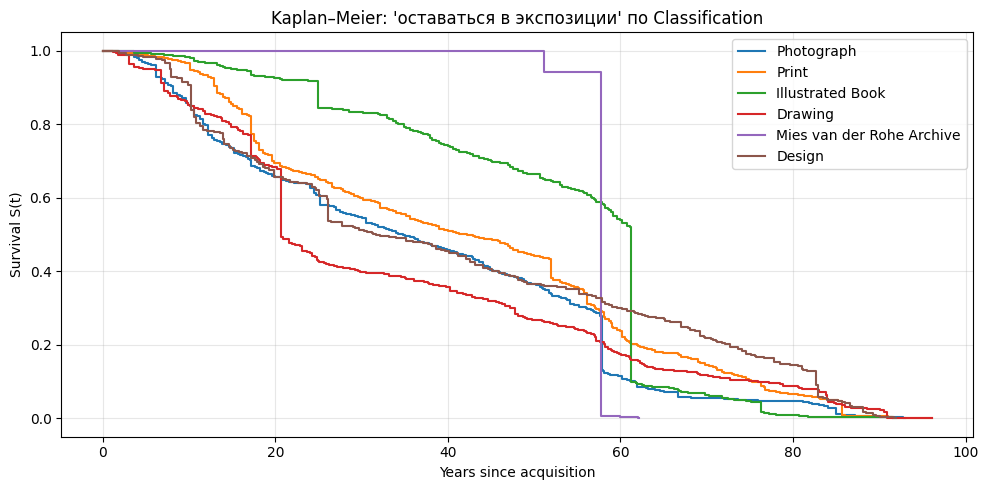

In [46]:
try:
    from lifelines import KaplanMeierFitter
    kmf = KaplanMeierFitter()

    d = df.dropna(subset=["DateAcquired","Is_OnView","Classification"]).copy()
    today = pd.Timestamp(datetime.now())
    d["T"] = (today - d["DateAcquired"]).dt.days / 365.25
    d = d[(d["T"] > 0) & np.isfinite(d["T"])]

    d["E"] = 1 - d["Is_OnView"].astype(int)  # событие = "ушёл с экспозиции"
    top_cls = d["Classification"].value_counts().head(6).index

    plt.figure(figsize=(10,5))
    for cls in top_cls:
        x = d[d["Classification"] == cls]
        if len(x) < 200:
            continue
        kmf.fit(durations=x["T"], event_observed=x["E"], label=str(cls))
        kmf.plot_survival_function(ci_show=False)

    plt.title("Kaplan–Meier: 'оставаться в экспозиции' по Classification")
    plt.xlabel("Years since acquisition")
    plt.ylabel("Survival S(t)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("KM не построился (бывает из-за данных/версий). Ошибка:", e)


In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

d = df.dropna(subset=["Acq_Year"]).copy()
d["Decade"] = (d["Acq_Year"] // 10) * 10

# документ на десятилетие
txt = (
    d.get("Title", "").fillna("").astype(str) + " " +
    d.get("Medium", "").fillna("").astype(str)
)
d["doc"] = txt

docs = d.groupby("Decade")["doc"].apply(lambda s: " ".join(s.tolist())).sort_index()
docs = docs[docs.str.len() > 50]  # выкинем пустые

vec = TfidfVectorizer(min_df=2, ngram_range=(1,2), stop_words="english")
X = vec.fit_transform(docs.values)
terms = np.array(vec.get_feature_names_out())

topk = 15
out = {}
for i, dec in enumerate(docs.index):
    row = X[i].toarray().ravel()
    idx = np.argsort(row)[::-1][:topk]
    out[int(dec)] = list(zip(terms[idx], row[idx]))

tfidf_by_decade = pd.DataFrame({
    "Decade": list(out.keys()),
    "TopTerms": [", ".join([t for t,_ in out[k]]) for k in out.keys()]
}).sort_values("Decade")

tfidf_by_decade


,Decade,TopTerms
0,1920,"lithograph, welt lithograph, world die, spiege..."
1,1930,"paper, lithograph, cuban sketch, untitled cuba..."
2,1940,"lithograph, print, plate, silver, silver print..."
3,1950,"lithograph, plate, etching, print, silver, sil..."
4,1960,"pencil, paper, plate, chicago il, page, print,..."
5,1970,"print, silver, silver print, lithograph, untit..."
6,1980,"print, silver, plate, silver print, printed, g..."
7,1990,"print, silver, untitled, gelatin, gelatin silv..."
8,2000,"paper, untitled, print, silver, gelatin, gelat..."
9,2010,"print, silver, gelatin, gelatin silver, silver..."


C:\Users\Shaim\AppData\Local\Temp\ipykernel_31108\3180774247.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = d.groupby("rarity_bin").agg(


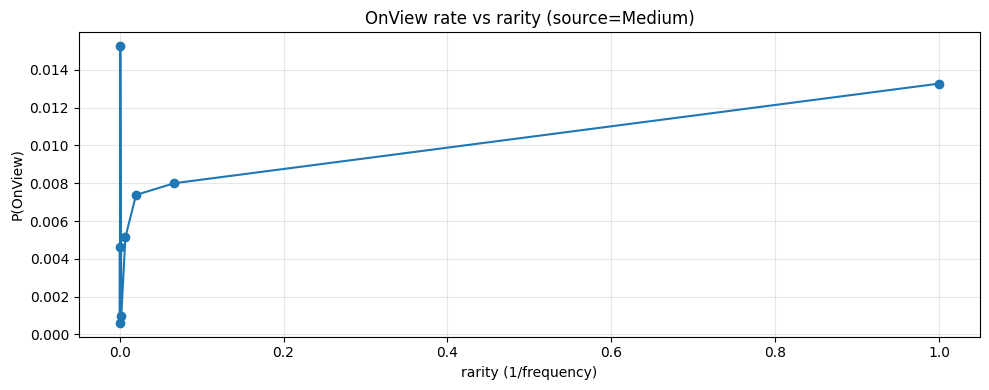

,rarity_bin,n,onview_rate,rarity_mid
0,"(-0.0009412, 0.000116]",34897,0.004642,0.000108
1,"(0.000116, 0.000384]",14673,0.000613,0.000207
2,"(0.000384, 0.00107]",14159,0.015255,0.000792
3,"(0.00107, 0.00338]",15330,0.000978,0.002024
4,"(0.00338, 0.0115]",15549,0.005145,0.006993
5,"(0.0115, 0.0357]",16114,0.007385,0.020000
6,"(0.0357, 0.111]",15493,0.008004,0.066667
7,"(0.111, 1.0]",31415,0.013274,1.000000


In [48]:
d = df.dropna(subset=["Is_OnView"]).copy()

# выбери источник редкости: Medium (если есть), иначе Classification
src = "Medium" if "Medium" in d.columns else ("Classification" if "Classification" in d.columns else None)
if not src:
    raise KeyError("Нет ни Medium, ни Classification для расчёта редкости")

s = d[src].fillna("Unknown").astype(str)
freq = s.value_counts()
d["rarity"] = 1.0 / s.map(freq)  # чем меньше freq, тем больше rarity

# бины по редкости
d["rarity_bin"] = pd.qcut(d["rarity"], q=10, duplicates="drop")
g = d.groupby("rarity_bin").agg(
    n=("Is_OnView","size"),
    onview_rate=("Is_OnView","mean"),
    rarity_mid=("rarity","median")
).reset_index().sort_values("rarity_mid")

plt.figure(figsize=(10,4))
plt.plot(g["rarity_mid"], g["onview_rate"], marker="o")
plt.title(f"OnView rate vs rarity (source={src})")
plt.xlabel("rarity (1/frequency)")
plt.ylabel("P(OnView)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

g


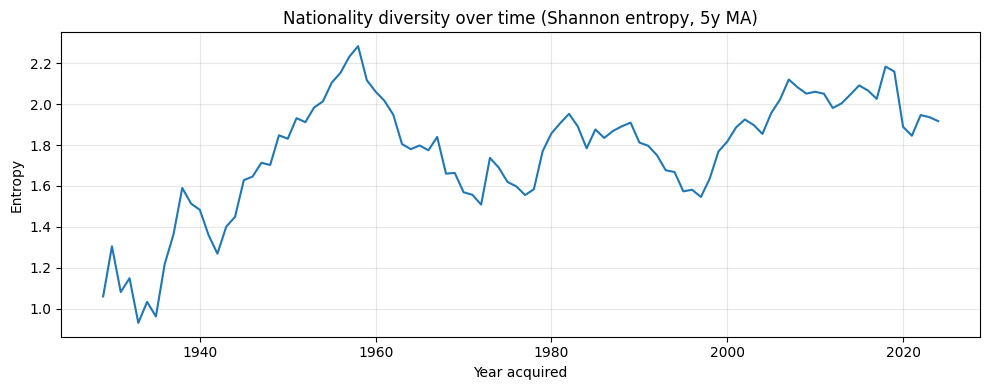

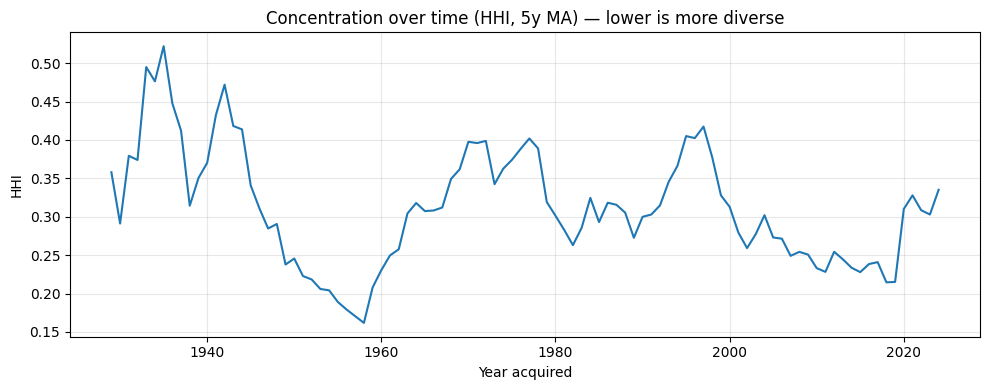

,Year,n,entropy,hhi,entropy_ma,hhi_ma
91,2020,2600,0.901355,0.668583,1.888792,0.310179
92,2021,920,1.910722,0.321588,1.845400,0.327899
93,2022,1218,2.412959,0.177692,1.946244,0.308483
94,2023,468,2.490113,0.141482,1.935721,0.302951
95,2024,862,1.867112,0.366420,1.916452,0.335153


In [49]:
d = df.dropna(subset=["Acq_Year"]).copy()
d = d[(d["Acq_Year"] >= 1900) & (d["Acq_Year"] <= pd.Timestamp(datetime.now()).year)]

def entropy(p):
    p = p[p>0]
    return float(-(p*np.log(p)).sum()) if len(p) else np.nan

def hhi(p):
    p = p[p>0]
    return float((p*p).sum()) if len(p) else np.nan

rows = []
for y, x in d.groupby("Acq_Year"):
    vc = x["Nationality_norm"].fillna("Unknown").astype(str).value_counts()
    p = (vc / vc.sum()).values
    rows.append({"Year": int(y), "n": len(x), "entropy": entropy(p), "hhi": hhi(p)})

ts = pd.DataFrame(rows).sort_values("Year")
ts["entropy_ma"] = ts["entropy"].rolling(5, min_periods=1).mean()
ts["hhi_ma"] = ts["hhi"].rolling(5, min_periods=1).mean()

plt.figure(figsize=(10,4))
plt.plot(ts["Year"], ts["entropy_ma"])
plt.title("Nationality diversity over time (Shannon entropy, 5y MA)")
plt.xlabel("Year acquired")
plt.ylabel("Entropy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(ts["Year"], ts["hhi_ma"])
plt.title("Concentration over time (HHI, 5y MA) — lower is more diverse")
plt.xlabel("Year acquired")
plt.ylabel("HHI")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ts.tail()


Artists: 11377
Gini total works : 0.8362565237952269
Gini onview works: 0.979980372439809


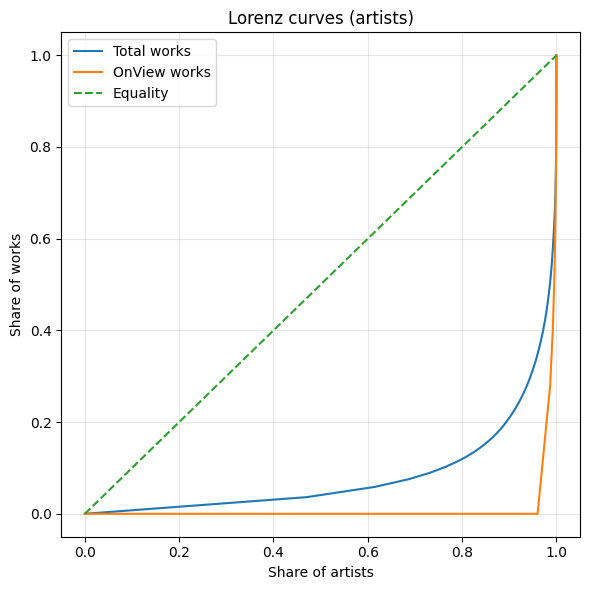

,ConstituentID,total,onview
1688,1973,208,54
3303,3832,1065,38
3993,4609,1314,34
2940,3418,39,30
7028,8595,2742,29
7141,9682,22,21
6079,7017,78,15
363,429,220,15
3240,3758,103,13
4450,5145,750,12


In [50]:
def gini(x):
    x = np.array(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    if np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

def lorenz_points(x):
    x = np.array(x, dtype=float)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    cum = np.cumsum(x)
    cum = np.insert(cum, 0, 0)
    share = cum / cum[-1] if cum[-1] > 0 else cum
    pop = np.linspace(0, 1, len(share))
    return pop, share

d = df.dropna(subset=["ConstituentID","Is_OnView"]).copy()
grp = d.groupby("ConstituentID").agg(
    total=("Is_OnView","size"),
    onview=("Is_OnView","sum")
).reset_index()

print("Artists:", len(grp))
print("Gini total works :", gini(grp["total"]))
print("Gini onview works:", gini(grp["onview"]))

p1, s1 = lorenz_points(grp["total"])
p2, s2 = lorenz_points(grp["onview"])

plt.figure(figsize=(6,6))
plt.plot(p1, s1, label="Total works")
plt.plot(p2, s2, label="OnView works")
plt.plot([0,1],[0,1], linestyle="--", label="Equality")
plt.title("Lorenz curves (artists)")
plt.xlabel("Share of artists")
plt.ylabel("Share of works")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# топ-10 по onview
top = grp.sort_values("onview", ascending=False).head(10)
top


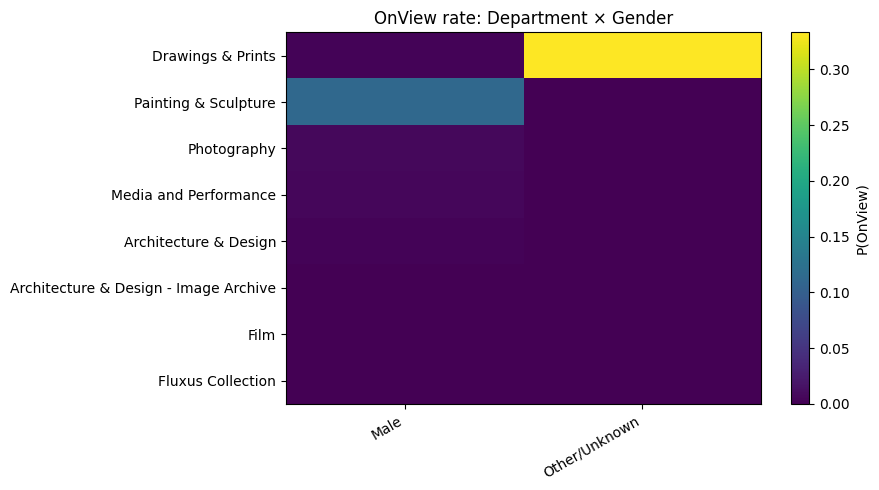

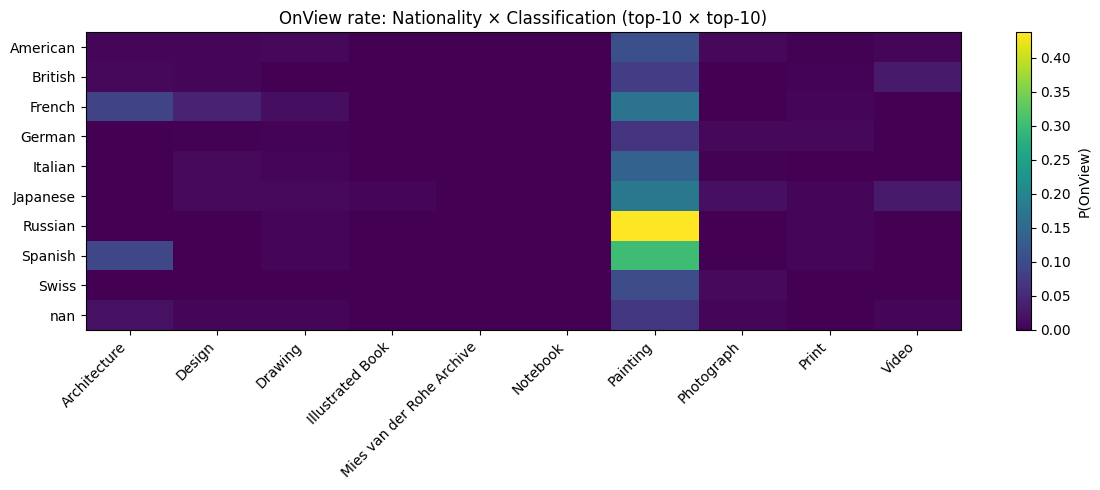

In [51]:
# 8A) Gender × Department (OnView rate)
d = df.dropna(subset=["Gender_norm","Department","Is_OnView"]).copy()
pivot = d.pivot_table(index="Department", columns="Gender_norm", values="Is_OnView", aggfunc="mean")
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).head(15).index]  # top 15 департаментов

plt.figure(figsize=(9,5))
plt.imshow(pivot.fillna(0).values, aspect="auto")
plt.xticks(range(pivot.shape[1]), pivot.columns, rotation=30, ha="right")
plt.yticks(range(pivot.shape[0]), pivot.index)
plt.title("OnView rate: Department × Gender")
plt.colorbar(label="P(OnView)")
plt.tight_layout()
plt.show()

# 8B) Top Nationality × Top Classification
d2 = df.dropna(subset=["Nationality_norm","Classification","Is_OnView"]).copy()
top_nat = d2["Nationality_norm"].value_counts().head(10).index
top_cls = d2["Classification"].value_counts().head(10).index
p2 = d2[d2["Nationality_norm"].isin(top_nat) & d2["Classification"].isin(top_cls)] \
    .pivot_table(index="Nationality_norm", columns="Classification", values="Is_OnView", aggfunc="mean")

plt.figure(figsize=(12,5))
plt.imshow(p2.fillna(0).values, aspect="auto")
plt.xticks(range(p2.shape[1]), p2.columns, rotation=45, ha="right")
plt.yticks(range(p2.shape[0]), p2.index)
plt.title("OnView rate: Nationality × Classification (top-10 × top-10)")
plt.colorbar(label="P(OnView)")
plt.tight_layout()
plt.show()


In [52]:
from sklearn.ensemble import IsolationForest

# числовые признаки: берём то, что есть
num_cols = [c for c in ["Lag_Years","Created_Year","Acq_Year","Height (cm)","Width (cm)","Depth (cm)","Weight (kg)","Duration (sec.)"] if c in df.columns]
if len(num_cols) < 2:
    raise ValueError("Слишком мало числовых колонок для outlier detection:", num_cols)

d = df.copy()
X = d[num_cols].copy()

# чистка явного мусора лагов
if "Lag_Years" in X.columns:
    X.loc[~X["Lag_Years"].between(-50, 300), "Lag_Years"] = np.nan

# простая импьютация медианой
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median(numeric_only=True))

iso = IsolationForest(n_estimators=300, contamination=0.01, random_state=42)
score = -iso.fit_predict(X)  # 1 = outlier, 0 = normal (после преобразования)
d["is_outlier"] = (iso.decision_function(X) < np.quantile(iso.decision_function(X), 0.01)).astype(int)
d["outlier_score"] = -iso.decision_function(X)

out = d.sort_values("outlier_score", ascending=False).head(20)
cols_show = [c for c in ["ObjectID","Title","DisplayName","Department","Classification","DateAcquired","Created_Year","Lag_Years","Is_OnView"] + num_cols if c in out.columns]
out[cols_show]


,ObjectID,Title,DisplayName,Department,Classification,DateAcquired,Created_Year,Lag_Years,Is_OnView,Lag_Years,Created_Year,Acq_Year,Height (cm),Width (cm),Depth (cm),Weight (kg),Duration (sec.)
97380,128836,The Farmers and The Helicopters,NaN,Media and Performance,Installation,2009-04-14,2006.0,3.0,0,3.0,2006.0,2009.0,883.921768,228.60,350.520701,498.956727,54000.0
143711,451364,Customer service representatives Christina Def...,LaToya Ruby Frazier,Photography,Photograph,2022-05-25,2019.0,3.0,0,3.0,2019.0,2022.0,243.840000,2164.08,259.080000,NaN,NaN
143713,451366,Text,LaToya Ruby Frazier,Photography,Photograph,2022-05-25,2019.0,3.0,0,3.0,2019.0,2022.0,243.840000,2164.08,259.080000,NaN,NaN
143712,451365,"Robert M. Defelice, UAW Local 1112, with his w...",LaToya Ruby Frazier,Photography,Photograph,2022-05-25,2019.0,3.0,0,3.0,2019.0,2022.0,243.840000,2164.08,259.080000,NaN,NaN
143715,451368,"Dan Morgan, UAW Local 1112, Shop Chairman, in ...",LaToya Ruby Frazier,Photography,Photograph,2022-05-25,2019.0,3.0,0,3.0,2019.0,2022.0,243.840000,2164.08,259.080000,NaN,NaN
143716,451369,"Dan Morgan, UAW Local 1112, Shop Chairman, at ...",LaToya Ruby Frazier,Photography,Photograph,2022-05-25,2019.0,3.0,0,3.0,2019.0,2022.0,243.840000,2164.08,259.080000,NaN,NaN
143717,451370,"Tawnya Morgan, UAW Local 1112, kissing her hus...",LaToya Ruby Frazier,Photography,Photograph,2022-05-25,2019.0,3.0,0,3.0,2019.0,2022.0,243.840000,2164.08,259.080000,NaN,NaN
143714,451367,Text,LaToya Ruby Frazier,Photography,Photograph,2022-05-25,2019.0,3.0,0,3.0,2019.0,2022.0,243.840000,2164.08,259.080000,NaN,NaN
143719,451372,Text,LaToya Ruby Frazier,Photography,Photograph,2022-05-25,2019.0,3.0,0,3.0,2019.0,2022.0,243.840000,2164.08,259.080000,NaN,NaN
143720,451373,"Werner Lange, 45-day vigil, standing on Ellswo...",LaToya Ruby Frazier,Photography,Photograph,2022-05-25,2019.0,3.0,0,3.0,2019.0,2022.0,243.840000,2164.08,259.080000,NaN,NaN


RF ROC-AUC: 0.9035172562216169 PR-AUC: 0.23535988800533125


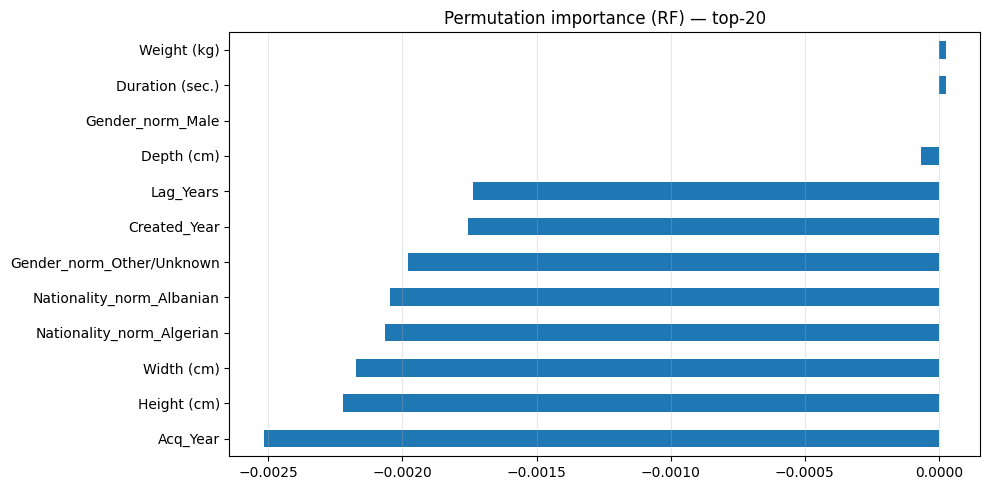

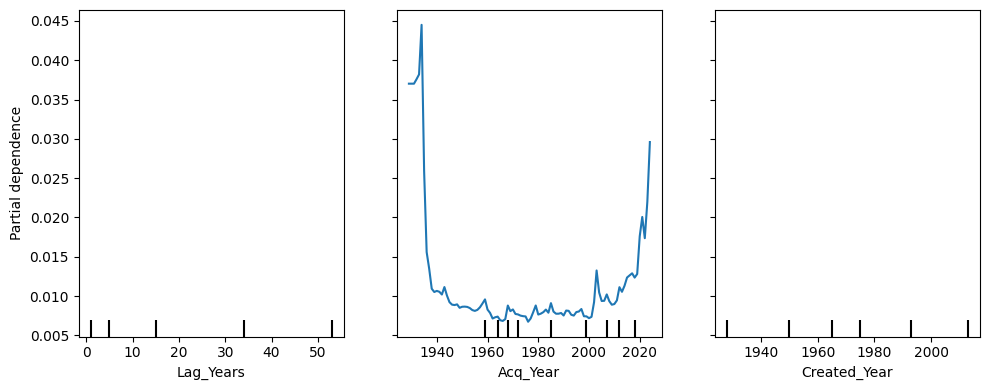

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

target = "Is_OnView"
feat_num = [c for c in ["Lag_Years","Created_Year","Acq_Year","Height (cm)","Width (cm)","Depth (cm)","Weight (kg)","Duration (sec.)"] if c in df.columns]
feat_cat = [c for c in ["Gender_norm","Nationality_norm","Classification","Department"] if c in df.columns]

d = df.dropna(subset=[target]).copy()
X = d[feat_num + feat_cat].copy()
y = d[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

num_pipe = Pipeline([("imp", SimpleImputer(strategy="median"))])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                     ("ohe", OneHotEncoder(handle_unknown="ignore"))])

pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, feat_num),
        ("cat", cat_pipe, feat_cat),
    ],
    remainder="drop"
)

rf = Pipeline(steps=[
    ("pre", pre),
    ("clf", RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced"))
])

rf.fit(X_train, y_train)
p = rf.predict_proba(X_test)[:,1]
print("RF ROC-AUC:", roc_auc_score(y_test, p), "PR-AUC:", average_precision_score(y_test, p))

# permutation importance
r = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
imp = r.importances_mean
order = np.argsort(imp)[::-1][:20]

# восстановим фичи
feature_names = []
pre_fitted = rf.named_steps["pre"]
for name, trans, cols in pre_fitted.transformers_:
    if name == "num":
        feature_names.extend(cols)
    elif name == "cat":
        ohe = trans.named_steps["ohe"]
        feature_names.extend(list(ohe.get_feature_names_out(cols)))

feature_names = np.array(feature_names)
top = pd.Series(imp[order], index=feature_names[order]).sort_values()

plt.figure(figsize=(10,5))
top.plot(kind="barh")
plt.title("Permutation importance (RF) — top-20")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# partial dependence (только для числовых, если есть)
num_for_pdp = [c for c in ["Lag_Years","Acq_Year","Created_Year","Height (cm)","Width (cm)"] if c in feat_num]
num_for_pdp = num_for_pdp[:3]
if num_for_pdp:
    fig, ax = plt.subplots(figsize=(10,4))
    PartialDependenceDisplay.from_estimator(rf, X_test, features=num_for_pdp, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("Нет подходящих числовых фич для Partial Dependence.")
